# Clean v3 analysis: irradiance-normalized current-collapse diagnostics

This notebook rebuilds the photovoltaic I–V analysis from the raw `.mat` files using a strict, auditable workflow.

## Revision principles

1. The principal current index is normalized by plane-of-array irradiance.
2. Clean references use the within-module clean median, not P95 of three points.
3. Quantitative summaries use unclipped normalized power.
4. Missing or failed clean traces stop the pipeline.
5. Dataset-reported and reconstructed I–V metrics are explicitly compared.
6. Current, voltage, and fill-factor contributions are decomposed.
7. Trace counts, labels, and electrical consistency are asserted.
8. Representative curves are selected symmetrically from condition medians.
9. Threshold analysis is descriptive and in-sample.
10. Tables, figures, manifests, environment metadata, and logs are exported.

The prior v2 notebook should remain unchanged as the provenance record for the earlier manuscript version.

## 0. Colab setup

In [1]:
import os, sys
if "google.colab" in sys.modules:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")

Mounted at /content/drive


## 1. Imports, configuration, and environment

In [2]:
from __future__ import annotations

import hashlib, json, os, platform, re, traceback
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.io import loadmat

BASE_DIR = Path(
    "/content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/"
    "Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData"
)
SEARCH_ROOTS = [Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives"), Path("/content/drive"), Path("/content")]
OUT_DIR = Path("/content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3")
FIG_DIR, TABLE_DIR, LOG_DIR, CURVE_DIR = [OUT_DIR/x for x in ("figures","tables","logs","curves")]
for d in (OUT_DIR, FIG_DIR, TABLE_DIR, LOG_DIR, CURVE_DIR): d.mkdir(parents=True, exist_ok=True)

EXPECTED_PANEL_COUNTS = {
    "M5_30112": {"Clean":3, "Soiled":3, "Shaded":3},
    "SP090P": {"Clean":3, "Soiled":3, "Shaded":2},
}
EXPECTED_TOTAL = sum(sum(v.values()) for v in EXPECTED_PANEL_COUNTS.values())
CONDITION_ORDER = ["Clean","Soiled","Shaded"]
PRIMARY_INDEX = "R_I_G"
ILLUSTRATIVE_THRESHOLD = 0.50
SAVE_DPI = 300
RANDOM_SEED = 42
VALIDATION_TOLERANCES_PCT = {"Isc":2.0,"Voc":2.0,"Pmpp":3.0,"Vmpp":3.0,"Impp":3.0}

plt.rcParams.update({"figure.dpi":110,"savefig.dpi":SAVE_DPI,"savefig.bbox":"tight","axes.grid":True,"grid.alpha":0.25})
environment = {
    "python":platform.python_version(), "platform":platform.platform(),
    "numpy":np.__version__, "pandas":pd.__version__, "scipy":scipy.__version__,
    "matplotlib":matplotlib.__version__, "primary_index":PRIMARY_INDEX,
    "illustrative_threshold":ILLUSTRATIVE_THRESHOLD, "expected_total_traces":EXPECTED_TOTAL,
}
(LOG_DIR/"environment.json").write_text(json.dumps(environment,indent=2),encoding="utf-8")
print(json.dumps(environment,indent=2))

{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "scipy": "1.16.3",
  "matplotlib": "3.10.0",
  "primary_index": "R_I_G",
  "illustrative_threshold": 0.5,
  "expected_total_traces": 17
}


## 2. File discovery and manifest

In [4]:
def has_mat_below(path: Path) -> bool:
    return path.is_dir() and any(path.rglob("*.mat"))


def find_processed_root(
    preferred: Path,
    roots: Sequence[Path],
    max_dirs: int = 30000,
) -> Path:
    if has_mat_below(preferred):
        return preferred

    for root in roots:
        if not root.is_dir():
            continue

        seen = 0

        for dirpath, _, _ in os.walk(root):
            seen += 1

            if seen > max_dirs:
                break

            path = Path(dirpath)

            if (
                path.name.lower() == "processeddata"
                and has_mat_below(path)
            ):
                return path

    raise FileNotFoundError(
        "Could not locate a ProcessedData directory containing .mat files. "
        "Set BASE_DIR explicitly."
    )


def discover_panel_folders(root: Path) -> Dict[str, Path]:
    panel_folders: Dict[str, Path] = {}

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue

        electrical_data_folder = child / "ElectricalData"

        if electrical_data_folder.is_dir():
            target_folder = electrical_data_folder
        else:
            target_folder = child

        if has_mat_below(target_folder):
            panel_folders[child.name] = target_folder

    return panel_folders


def infer_condition(filename: str) -> str:
    name = Path(filename).name.lower()

    if any(
        token in name
        for token in ("shadow", "shade", "shad")
    ):
        return "Shaded"

    if any(
        token in name
        for token in ("dirt", "soil", "dust")
    ):
        return "Soiled"

    if "clean" in name:
        return "Clean"

    return "Other"


def sha256(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    file_hash = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            block = file.read(chunk_size)

            if not block:
                break

            file_hash.update(block)

    return file_hash.hexdigest()


# ---------------------------------------------------------------------
# Locate the processed-data directory
# ---------------------------------------------------------------------

PROCESSED_ROOT = find_processed_root(
    preferred=BASE_DIR,
    roots=SEARCH_ROOTS,
)

PANEL_FOLDERS = discover_panel_folders(PROCESSED_ROOT)

missing_panels = sorted(
    set(EXPECTED_PANEL_COUNTS) - set(PANEL_FOLDERS)
)

if missing_panels:
    raise RuntimeError(
        f"Expected panel folders are missing: {missing_panels}\n"
        f"Detected panel folders: {sorted(PANEL_FOLDERS)}\n"
        f"Processed-data root: {PROCESSED_ROOT}"
    )


# ---------------------------------------------------------------------
# Build the file manifest
# ---------------------------------------------------------------------

manifest_rows = []

for panel, folder in PANEL_FOLDERS.items():
    if panel not in EXPECTED_PANEL_COUNTS:
        continue

    mat_files = sorted(folder.rglob("*.mat"))

    for filepath in mat_files:
        manifest_rows.append(
            {
                "panel": panel,
                "trace": filepath.stem,
                "condition": infer_condition(filepath.name),
                "file": str(filepath),
                "size_bytes": filepath.stat().st_size,
                "sha256": sha256(filepath),
            }
        )


manifest = pd.DataFrame(manifest_rows)

if manifest.empty:
    raise RuntimeError(
        "No expected .mat files were found under:\n"
        f"{PROCESSED_ROOT}"
    )


# ---------------------------------------------------------------------
# Reject files whose condition cannot be inferred
# ---------------------------------------------------------------------

unclassified = manifest.loc[
    manifest["condition"] == "Other",
    ["panel", "trace", "file"],
]

if not unclassified.empty:
    raise RuntimeError(
        "The following files could not be classified as "
        "Clean, Soiled, or Shaded:\n\n"
        + unclassified.to_string(index=False)
    )


# ---------------------------------------------------------------------
# Save and inspect the manifest
# ---------------------------------------------------------------------

manifest_path = TABLE_DIR / "file_manifest_preload.csv"

manifest.to_csv(
    manifest_path,
    index=False,
)

print("Processed-data root:")
print(PROCESSED_ROOT)

print("\nDetected panel folders:")
for panel, folder in PANEL_FOLDERS.items():
    print(f"  {panel}: {folder}")

print("\nTrace counts:")
print(
    manifest.groupby(
        ["panel", "condition"],
        observed=False,
    ).size()
)

print("\nTotal number of .mat files:", len(manifest))
print("Manifest saved to:", manifest_path)

Processed-data root:
/content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData

Detected panel folders:
  M5_30112: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData/M5_30112/ElectricalData
  SP090P: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData/SP090P/ElectricalData

Trace counts:
panel     condition
M5_30112  Clean        3
          Shaded       3
          Soiled       3
SP090P    Clean        3
          Shaded       2
          Soiled       3
dtype: int64

Total number of .mat files: 17
Manifest saved to: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/file_manifest_preload.csv


## 3. Strict loading and feature extraction

In [6]:
def squeeze_value(x: Any) -> Any:
    if isinstance(x,np.ndarray):
        x=np.squeeze(x)
        if x.shape==(): return x.item()
    return x

def safe_float(x: Any) -> Optional[float]:
    try:
        x=squeeze_value(x)
        if isinstance(x,(float,int,np.floating,np.integer)): return float(x)
    except Exception: pass
    return None

def is_vector(x: Any) -> bool:
    return isinstance(x,np.ndarray) and np.squeeze(x).ndim==1 and np.squeeze(x).size>=5

def find_key(d: Dict[str,Any], patterns: Sequence[str]) -> Optional[str]:
    for pat in patterns:
        rx=re.compile(pat,re.I)
        for k in d:
            if rx.search(k): return k
    return None

def load_mat_strict(path: Path) -> Dict[str,Any]:
    try: raw=loadmat(path,squeeze_me=False,struct_as_record=False)
    except NotImplementedError as e:
        raise RuntimeError(f"{path.name} appears to be MATLAB v7.3/HDF5; use h5py/mat73 or convert it.") from e
    except Exception as e:
        if "hdf5" in str(e).lower() or "7.3" in str(e).lower():
            raise RuntimeError(f"{path.name} requires an HDF5-compatible MATLAB reader.") from e
        raise
    return {k:squeeze_value(v) for k,v in raw.items() if not k.startswith("__")}

def normalize_sign(v: np.ndarray, i: np.ndarray) -> Tuple[np.ndarray,np.ndarray,bool]:
    low=v<=np.nanpercentile(v,15)
    flip=bool(np.isfinite(np.nanmedian(i[low])) and np.nanmedian(i[low])<0)
    return v, (-i if flip else i), flip

def extract_vectors(d: Dict[str,Any], path: Path):
    vk="Vpanel" if "Vpanel" in d else find_key(d,[r"^vpanel$",r"^voltage$",r"^volt",r"^v$"])
    ik="Ipanel" if "Ipanel" in d else find_key(d,[r"^ipanel$",r"^current$",r"^curr",r"^i$"])
    if not vk or not ik or not is_vector(d.get(vk)) or not is_vector(d.get(ik)):
        raise KeyError(f"Explicit I-V vectors not found in {path.name}; fields={sorted(d)}")
    v=np.asarray(np.squeeze(d[vk]),float); i=np.asarray(np.squeeze(d[ik]),float)
    n=min(v.size,i.size); v,i=v[:n],i[:n]
    ok=np.isfinite(v)&np.isfinite(i); v,i=v[ok],i[ok]
    if len(v)<5: raise ValueError(f"Too few finite points in {path.name}")
    order=np.argsort(v); v,i=v[order],i[order]
    v,i,flipped=normalize_sign(v,i)
    if np.nanmax(v)<=0 or np.nanmax(i)<=0 or np.nanmax(v*i)<=0: raise ValueError(f"Nonphysical I-V range in {path.name}")
    return v,i,vk,ik,flipped

def local_linear_value(x,y,x0,n_points=6):
    x=np.asarray(x,float); y=np.asarray(y,float); ok=np.isfinite(x)&np.isfinite(y); x,y=x[ok],y[ok]
    if len(x)<2: return np.nan
    idx=np.argsort(np.abs(x-x0))[:min(n_points,len(x))]; xl,yl=x[idx],y[idx]
    if np.unique(xl).size<2: return float(np.nanmean(yl))
    m,b=np.polyfit(xl,yl,1); return float(m*x0+b)

def reconstruct_metrics(v,i):
    p=v*i; k=int(np.nanargmax(p))
    return {"Isc_reconstructed_A":local_linear_value(v,i,0.0),"Voc_reconstructed_V":local_linear_value(i,v,0.0),
            "Pmpp_reconstructed_W":float(p[k]),"Vmpp_reconstructed_V":float(v[k]),"Impp_reconstructed_A":float(i[k])}

def reported_metrics(d):
    mapping={"Isc":"Isc_reported_A","Voc":"Voc_reported_V","Pmpp":"Pmpp_reported_W","Vmpp":"Vmpp_reported_V","Impp":"Impp_reported_A"}
    return {target:(float(safe_float(d.get(source))) if safe_float(d.get(source)) is not None else np.nan) for source,target in mapping.items()}

def environmental_fields(d):
    gk="IRR" if "IRR" in d else find_key(d,[r"irr",r"irradi",r"poa",r"w/m"])
    tk="T" if "T" in d else find_key(d,[r"temp",r"tpanel",r"t_mod",r"tmod",r"^t$"])
    g=safe_float(d.get(gk)) if gk else None; t=safe_float(d.get(tk)) if tk else None
    if g is None or t is None: raise ValueError("Missing scalar irradiance or module temperature.")
    return float(g),float(t),str(gk),str(tk)

## 4. Load all traces; stop on any error

In [9]:
# ================================================================
# 3. Strict .mat loading and I–V feature-extraction functions
# Run this entire cell before Section 4
# ================================================================

from typing import Any, Dict, Optional, Sequence, Tuple

import numpy as np
from scipy.io import loadmat


def squeeze_value(value: Any) -> Any:
    """
    Remove singleton dimensions from MATLAB-loaded values.
    Convert zero-dimensional arrays to Python scalars.
    """
    if isinstance(value, np.ndarray):
        value = np.squeeze(value)

        if value.shape == ():
            return value.item()

    return value


def safe_float(value: Any) -> Optional[float]:
    """
    Convert a scalar-like MATLAB value to float.
    Return None when conversion is not possible.
    """
    try:
        value = squeeze_value(value)

        if isinstance(
            value,
            (
                float,
                int,
                np.floating,
                np.integer,
            ),
        ):
            return float(value)

    except Exception:
        return None

    return None


def is_numeric_vector(value: Any) -> bool:
    """
    Return True when value is a one-dimensional numeric vector
    containing at least five elements.
    """
    if not isinstance(value, np.ndarray):
        return False

    array = np.asarray(
        np.squeeze(value)
    )

    return (
        array.ndim == 1
        and array.size >= 5
        and np.issubdtype(
            array.dtype,
            np.number,
        )
    )


def find_key(
    data: Dict[str, Any],
    patterns: Sequence[str],
) -> Optional[str]:
    """
    Find the first dictionary key matching one of the supplied
    regular-expression patterns.
    """
    for pattern in patterns:
        regular_expression = re.compile(
            pattern,
            flags=re.IGNORECASE,
        )

        for key in data:
            if regular_expression.search(key):
                return key

    return None


def load_mat_strict(
    mat_path: Path,
) -> Dict[str, Any]:
    """
    Load a MATLAB file without silently swallowing errors.

    MATLAB v7.3/HDF5 files require an HDF5-compatible reader and
    therefore trigger a clear error message.
    """
    try:
        raw_data = loadmat(
            mat_path,
            squeeze_me=False,
            struct_as_record=False,
        )

    except NotImplementedError as error:
        raise RuntimeError(
            f"{mat_path.name} appears to be a MATLAB v7.3/HDF5 file. "
            "scipy.io.loadmat cannot read this format."
        ) from error

    except Exception as error:
        message = str(error).lower()

        if (
            "hdf5" in message
            or "7.3" in message
            or "unknown mat file type" in message
        ):
            raise RuntimeError(
                f"{mat_path.name} appears to require an "
                "HDF5-compatible MATLAB reader."
            ) from error

        raise

    cleaned_data = {
        key: squeeze_value(value)
        for key, value in raw_data.items()
        if not key.startswith("__")
    }

    return cleaned_data


def normalize_current_sign(
    voltage: np.ndarray,
    current: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, bool]:
    """
    Normalize the PV sign convention so generated current is positive.

    The current sign is assessed using the low-voltage portion of the
    measured I–V curve.
    """
    voltage = np.asarray(
        voltage,
        dtype=float,
    )

    current = np.asarray(
        current,
        dtype=float,
    )

    low_voltage_limit = np.nanpercentile(
        voltage,
        15,
    )

    low_voltage_mask = (
        voltage <= low_voltage_limit
    )

    reference_current = np.nanmedian(
        current[low_voltage_mask]
    )

    sign_flipped = bool(
        np.isfinite(reference_current)
        and reference_current < 0
    )

    if sign_flipped:
        current = -current

    return (
        voltage,
        current,
        sign_flipped,
    )


def extract_iv_vectors(
    data: Dict[str, Any],
    mat_path: Path,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    str,
    str,
    bool,
]:
    """
    Extract voltage and current vectors from a loaded MATLAB file.

    The known dataset fields Vpanel and Ipanel are preferred. Alternative
    names are accepted only when they match explicit field-name patterns.
    """
    if "Vpanel" in data:
        voltage_key = "Vpanel"
    else:
        voltage_key = find_key(
            data,
            [
                r"^vpanel$",
                r"^voltage$",
                r"^volt",
                r"^v$",
            ],
        )

    if "Ipanel" in data:
        current_key = "Ipanel"
    else:
        current_key = find_key(
            data,
            [
                r"^ipanel$",
                r"^current$",
                r"^curr",
                r"^i$",
            ],
        )

    if voltage_key is None:
        raise KeyError(
            f"No voltage vector was identified in {mat_path.name}. "
            f"Available fields: {sorted(data.keys())}"
        )

    if current_key is None:
        raise KeyError(
            f"No current vector was identified in {mat_path.name}. "
            f"Available fields: {sorted(data.keys())}"
        )

    if not is_numeric_vector(
        data[voltage_key]
    ):
        raise ValueError(
            f"Voltage field '{voltage_key}' is not a valid numeric "
            f"vector in {mat_path.name}."
        )

    if not is_numeric_vector(
        data[current_key]
    ):
        raise ValueError(
            f"Current field '{current_key}' is not a valid numeric "
            f"vector in {mat_path.name}."
        )

    voltage = np.asarray(
        np.squeeze(data[voltage_key]),
        dtype=float,
    )

    current = np.asarray(
        np.squeeze(data[current_key]),
        dtype=float,
    )

    if voltage.size != current.size:
        raise ValueError(
            f"Voltage and current vectors have different lengths in "
            f"{mat_path.name}: "
            f"{voltage.size} versus {current.size}."
        )

    finite_mask = (
        np.isfinite(voltage)
        & np.isfinite(current)
    )

    voltage = voltage[finite_mask]
    current = current[finite_mask]

    if voltage.size < 5:
        raise ValueError(
            f"Only {voltage.size} finite I–V points remain in "
            f"{mat_path.name}."
        )

    sort_order = np.argsort(
        voltage
    )

    voltage = voltage[sort_order]
    current = current[sort_order]

    (
        voltage,
        current,
        sign_flipped,
    ) = normalize_current_sign(
        voltage,
        current,
    )

    if np.nanmax(voltage) <= 0:
        raise ValueError(
            f"No positive voltage values were found in {mat_path.name}."
        )

    if np.nanmax(current) <= 0:
        raise ValueError(
            f"No positive generated-current values were found in "
            f"{mat_path.name}."
        )

    power = voltage * current

    if np.nanmax(power) <= 0:
        raise ValueError(
            f"No positive generated-power region was found in "
            f"{mat_path.name}."
        )

    return (
        voltage,
        current,
        voltage_key,
        current_key,
        sign_flipped,
    )


def local_linear_value(
    x: np.ndarray,
    y: np.ndarray,
    x_target: float,
    number_of_points: int = 6,
) -> float:
    """
    Estimate y at x_target using a local first-order fit to the nearest
    measured points.
    """
    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    finite_mask = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[finite_mask]
    y = y[finite_mask]

    if x.size < 2:
        return float("nan")

    nearest_indices = np.argsort(
        np.abs(x - x_target)
    )[
        :min(
            number_of_points,
            x.size,
        )
    ]

    local_x = x[nearest_indices]
    local_y = y[nearest_indices]

    if np.unique(local_x).size < 2:
        return float(
            np.nanmean(local_y)
        )

    slope, intercept = np.polyfit(
        local_x,
        local_y,
        deg=1,
    )

    estimate = (
        intercept
        + slope * x_target
    )

    return float(estimate)


def reconstruct_iv_metrics(
    voltage: np.ndarray,
    current: np.ndarray,
) -> Dict[str, float]:
    """
    Reconstruct Isc, Voc, MPP power, MPP voltage, and MPP current
    directly from the measured I–V vectors.
    """
    voltage = np.asarray(
        voltage,
        dtype=float,
    )

    current = np.asarray(
        current,
        dtype=float,
    )

    power = voltage * current

    if not np.isfinite(power).any():
        raise ValueError(
            "The reconstructed power vector contains no finite values."
        )

    mpp_index = int(
        np.nanargmax(power)
    )

    isc_reconstructed = local_linear_value(
        x=voltage,
        y=current,
        x_target=0.0,
    )

    voc_reconstructed = local_linear_value(
        x=current,
        y=voltage,
        x_target=0.0,
    )

    return {
        "Isc_reconstructed_A": float(
            isc_reconstructed
        ),
        "Voc_reconstructed_V": float(
            voc_reconstructed
        ),
        "Pmpp_reconstructed_W": float(
            power[mpp_index]
        ),
        "Vmpp_reconstructed_V": float(
            voltage[mpp_index]
        ),
        "Impp_reconstructed_A": float(
            current[mpp_index]
        ),
    }


def extract_reported_metrics(
    data: Dict[str, Any],
) -> Dict[str, float]:
    """
    Extract dataset-reported scalar electrical quantities.
    """
    field_mapping = {
        "Isc": "Isc_reported_A",
        "Voc": "Voc_reported_V",
        "Pmpp": "Pmpp_reported_W",
        "Vmpp": "Vmpp_reported_V",
        "Impp": "Impp_reported_A",
    }

    output = {}

    for source_field, output_field in field_mapping.items():
        value = safe_float(
            data.get(source_field)
        )

        if value is None:
            output[output_field] = float(
                "nan"
            )
        else:
            output[output_field] = float(
                value
            )

    return output


def extract_environmental_fields(
    data: Dict[str, Any],
) -> Tuple[
    float,
    float,
    str,
    str,
]:
    """
    Extract scalar plane-of-array irradiance and module temperature.
    """
    if "IRR" in data:
        irradiance_key = "IRR"
    else:
        irradiance_key = find_key(
            data,
            [
                r"\birr\b",
                r"irradi",
                r"poa",
                r"w/m",
            ],
        )

    if "T" in data:
        temperature_key = "T"
    else:
        temperature_key = find_key(
            data,
            [
                r"^t$",
                r"\btemp\b",
                r"tpanel",
                r"t_mod",
                r"tmod",
            ],
        )

    if irradiance_key is None:
        raise KeyError(
            "No irradiance field was identified."
        )

    if temperature_key is None:
        raise KeyError(
            "No temperature field was identified."
        )

    irradiance = safe_float(
        data.get(irradiance_key)
    )

    temperature = safe_float(
        data.get(temperature_key)
    )

    if irradiance is None:
        raise ValueError(
            f"Irradiance field '{irradiance_key}' is not a scalar value."
        )

    if temperature is None:
        raise ValueError(
            f"Temperature field '{temperature_key}' is not a scalar value."
        )

    if irradiance <= 0:
        raise ValueError(
            f"Invalid irradiance value: {irradiance}"
        )

    return (
        float(irradiance),
        float(temperature),
        irradiance_key,
        temperature_key,
    )


print(
    "Section 3 functions defined successfully."
)

print(
    "extract_iv_vectors available:",
    callable(extract_iv_vectors),
)

print(
    "load_mat_strict available:",
    callable(load_mat_strict),
)

print(
    "reconstruct_iv_metrics available:",
    callable(reconstruct_iv_metrics),
)

Section 3 functions defined successfully.
extract_iv_vectors available: True
load_mat_strict available: True
reconstruct_iv_metrics available: True


In [10]:
trace_rows = []
curve_store = {}
load_errors = []

for row in manifest.itertuples(index=False):
    path = Path(row.file)

    try:
        data = load_mat_strict(path)

        voltage, current, voltage_key, current_key, sign_flipped = (
            extract_iv_vectors(
                data=data,
                mat_path=path,
            )
        )

        irradiance, temperature, irradiance_key, temperature_key = (
            extract_environmental_fields(data)
        )

        reported = extract_reported_metrics(data)

        reconstructed = reconstruct_iv_metrics(
            voltage=voltage,
            current=current,
        )

        merged_metrics = {
            **reported,
            **reconstructed,
        }

        selected_metrics = {}
        source_labels = {}

        metric_specs = {
            "Isc": (
                "Isc_reported_A",
                "Isc_reconstructed_A",
                "Isc_A",
            ),
            "Voc": (
                "Voc_reported_V",
                "Voc_reconstructed_V",
                "Voc_V",
            ),
            "Pmpp": (
                "Pmpp_reported_W",
                "Pmpp_reconstructed_W",
                "Pmpp_W",
            ),
            "Vmpp": (
                "Vmpp_reported_V",
                "Vmpp_reconstructed_V",
                "Vmpp_V",
            ),
            "Impp": (
                "Impp_reported_A",
                "Impp_reconstructed_A",
                "Impp_A",
            ),
        }

        for metric_name, (
            reported_name,
            reconstructed_name,
            selected_name,
        ) in metric_specs.items():

            reported_value = merged_metrics[reported_name]
            reconstructed_value = merged_metrics[reconstructed_name]

            if np.isfinite(reported_value):
                selected_metrics[selected_name] = float(
                    abs(reported_value)
                )
                source_labels[f"{metric_name}_source"] = (
                    "dataset_reported"
                )

            elif np.isfinite(reconstructed_value):
                selected_metrics[selected_name] = float(
                    abs(reconstructed_value)
                )
                source_labels[f"{metric_name}_source"] = (
                    "reconstructed"
                )

            else:
                raise ValueError(
                    f"Neither dataset-reported nor reconstructed "
                    f"{metric_name} is finite for {path.name}."
                )

        denominator = (
            selected_metrics["Voc_V"]
            * selected_metrics["Isc_A"]
        )

        if denominator <= 0:
            raise ValueError(
                f"Invalid FF denominator for {path.name}: "
                f"Voc × Isc = {denominator}"
            )

        ff = (
            selected_metrics["Pmpp_W"]
            / denominator
        )

        trace_key = f"{row.panel}::{row.trace}"

        curve_store[trace_key] = {
            "voltage_V": voltage,
            "current_A": current,
            "power_W": voltage * current,
        }

        trace_rows.append(
            {
                "panel": row.panel,
                "trace": row.trace,
                "condition": row.condition,
                "file": row.file,
                "trace_key": trace_key,

                "G_Wm2": irradiance,
                "T_C": temperature,

                "voltage_field": voltage_key,
                "current_field": current_key,
                "irradiance_field": irradiance_key,
                "temperature_field": temperature_key,

                "current_sign_flipped": sign_flipped,

                **reported,
                **reconstructed,
                **selected_metrics,
                **source_labels,

                "FF": float(ff),
                "load_status": "success",
            }
        )

    except Exception as exc:
        load_errors.append(
            {
                "panel": row.panel,
                "trace": row.trace,
                "file": row.file,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
                "traceback": traceback.format_exc(),
            }
        )


if load_errors:
    error_df = pd.DataFrame(load_errors)

    error_path = LOG_DIR / "load_errors.csv"

    error_df.to_csv(
        error_path,
        index=False,
    )

    raise RuntimeError(
        "One or more expected traces failed to load. "
        "The analysis has been stopped to protect the clean references.\n\n"
        + error_df[
            [
                "panel",
                "trace",
                "error_type",
                "error_message",
            ]
        ].to_string(index=False)
        + f"\n\nDetailed errors were saved to:\n{error_path}"
    )


df = (
    pd.DataFrame(trace_rows)
    .sort_values(
        [
            "panel",
            "condition",
            "trace",
        ]
    )
    .reset_index(drop=True)
)


manifest["load_status"] = "success"

manifest.to_csv(
    TABLE_DIR / "file_manifest_final.csv",
    index=False,
)


print("Trace counts after loading:")

print(
    df.groupby(
        [
            "panel",
            "condition",
        ],
        observed=False,
    ).size()
)

print("\nLoaded traces:", len(df))

print("\nElectrical metric sources:")

for metric in [
    "Isc",
    "Voc",
    "Pmpp",
    "Vmpp",
    "Impp",
]:
    source_column = f"{metric}_source"

    print(f"\n{metric}:")
    print(
        df[source_column]
        .value_counts(
            dropna=False
        )
    )

print(
    "\nAll expected traces were loaded successfully. "
    "No silent file exclusion occurred."
)

Trace counts after loading:
panel     condition
M5_30112  Clean        3
          Shaded       3
          Soiled       3
SP090P    Clean        3
          Shaded       2
          Soiled       3
dtype: int64

Loaded traces: 17

Electrical metric sources:

Isc:
Isc_source
dataset_reported    17
Name: count, dtype: int64

Voc:
Voc_source
dataset_reported    17
Name: count, dtype: int64

Pmpp:
Pmpp_source
dataset_reported    17
Name: count, dtype: int64

Vmpp:
Vmpp_source
dataset_reported    17
Name: count, dtype: int64

Impp:
Impp_source
dataset_reported    17
Name: count, dtype: int64

All expected traces were loaded successfully. No silent file exclusion occurred.


## 5. Integrity checks

In [12]:
def assert_expected_counts(data: pd.DataFrame) -> None:
    """
    Confirm that all expected traces and condition counts are present.
    """
    if len(data) != EXPECTED_TOTAL:
        raise AssertionError(
            f"Expected {EXPECTED_TOTAL} traces, "
            f"but loaded {len(data)}."
        )

    for panel, expected_conditions in EXPECTED_PANEL_COUNTS.items():
        panel_data = data.loc[
            data["panel"] == panel
        ]

        if panel_data.empty:
            raise AssertionError(
                f"Missing expected panel: {panel}"
            )

        actual_counts = (
            panel_data
            .groupby(
                "condition",
                observed=False,
            )
            .size()
            .to_dict()
        )

        if actual_counts != expected_conditions:
            raise AssertionError(
                f"Unexpected condition counts for {panel}.\n"
                f"Expected: {expected_conditions}\n"
                f"Observed: {actual_counts}"
            )


# ---------------------------------------------------------------------
# Trace-count and label checks
# ---------------------------------------------------------------------

assert_expected_counts(df)

if set(df["condition"]) != set(CONDITION_ORDER):
    raise AssertionError(
        "Unexpected condition labels were found.\n"
        f"Expected: {sorted(CONDITION_ORDER)}\n"
        f"Observed: {sorted(df['condition'].unique())}"
    )


# ---------------------------------------------------------------------
# Environmental-field checks
# ---------------------------------------------------------------------

if not df["G_Wm2"].notna().all():
    missing = df.loc[
        df["G_Wm2"].isna(),
        ["panel", "trace", "condition"],
    ]

    raise AssertionError(
        "Missing irradiance values were found:\n\n"
        + missing.to_string(index=False)
    )

if not df["T_C"].notna().all():
    missing = df.loc[
        df["T_C"].isna(),
        ["panel", "trace", "condition"],
    ]

    raise AssertionError(
        "Missing temperature values were found:\n\n"
        + missing.to_string(index=False)
    )

if not (df["G_Wm2"] > 0).all():
    invalid = df.loc[
        df["G_Wm2"] <= 0,
        ["panel", "trace", "condition", "G_Wm2"],
    ]

    raise AssertionError(
        "Non-positive irradiance values were found:\n\n"
        + invalid.to_string(index=False)
    )


# ---------------------------------------------------------------------
# Electrical-value checks
# ---------------------------------------------------------------------

positive_columns = [
    "Isc_A",
    "Voc_V",
    "Pmpp_W",
    "Vmpp_V",
    "Impp_A",
]

for column in positive_columns:
    if not df[column].notna().all():
        missing = df.loc[
            df[column].isna(),
            ["panel", "trace", "condition", column],
        ]

        raise AssertionError(
            f"Missing values were found in {column}:\n\n"
            + missing.to_string(index=False)
        )

    if not (df[column] > 0).all():
        invalid = df.loc[
            df[column] <= 0,
            ["panel", "trace", "condition", column],
        ]

        raise AssertionError(
            f"Non-positive values were found in {column}:\n\n"
            + invalid.to_string(index=False)
        )


# ---------------------------------------------------------------------
# Fill-factor checks
# ---------------------------------------------------------------------

if not df["FF"].notna().all():
    missing = df.loc[
        df["FF"].isna(),
        ["panel", "trace", "condition", "FF"],
    ]

    raise AssertionError(
        "Missing fill-factor values were found:\n\n"
        + missing.to_string(index=False)
    )

if not df["FF"].between(0, 1).all():
    invalid = df.loc[
        ~df["FF"].between(0, 1),
        [
            "panel",
            "trace",
            "condition",
            "FF",
            "Pmpp_W",
            "Voc_V",
            "Isc_A",
        ],
    ]

    raise AssertionError(
        "Fill-factor values outside the physical interval "
        "0 < FF <= 1 were found:\n\n"
        + invalid.to_string(index=False)
    )


# ---------------------------------------------------------------------
# Pmpp consistency with Vmpp × Impp
# ---------------------------------------------------------------------

df["Pmpp_from_selected_mpp_W"] = (
    df["Vmpp_V"]
    * df["Impp_A"]
)

df["Pmpp_mpp_consistency_pct"] = (
    100.0
    * (
        df["Pmpp_W"]
        - df["Pmpp_from_selected_mpp_W"]
    ).abs()
    / df["Pmpp_W"]
)

mpp_inconsistent = df.loc[
    df["Pmpp_mpp_consistency_pct"] > 5.0,
    [
        "panel",
        "trace",
        "condition",
        "Pmpp_W",
        "Vmpp_V",
        "Impp_A",
        "Pmpp_from_selected_mpp_W",
        "Pmpp_mpp_consistency_pct",
    ],
]

if not mpp_inconsistent.empty:
    raise AssertionError(
        "Pmpp differs from Vmpp × Impp by more than 5% "
        "for one or more traces:\n\n"
        + mpp_inconsistent.to_string(index=False)
    )


# ---------------------------------------------------------------------
# Optional diagnostic summaries
# ---------------------------------------------------------------------

print("All trace-count, label, environmental, and electrical checks passed.")

print("\nIrradiance range by panel:")
print(
    df.groupby(
        "panel",
        observed=False,
    )["G_Wm2"]
    .agg(
        [
            "min",
            "max",
            "mean",
        ]
    )
)

print("\nTemperature range by panel:")
print(
    df.groupby(
        "panel",
        observed=False,
    )["T_C"]
    .agg(
        [
            "min",
            "max",
            "mean",
        ]
    )
)

print("\nFill-factor range by condition:")
print(
    df.groupby(
        [
            "panel",
            "condition",
        ],
        observed=False,
    )["FF"]
    .agg(
        [
            "min",
            "max",
            "mean",
        ]
    )
)

print(
    "\nMaximum Pmpp versus Vmpp × Impp discrepancy:",
    f"{df['Pmpp_mpp_consistency_pct'].max():.4f}%",
)

All trace-count, label, environmental, and electrical checks passed.

Irradiance range by panel:
            min    max        mean
panel                             
M5_30112  900.0  990.0  933.555556
SP090P    920.0  970.0  942.000000

Temperature range by panel:
           min   max       mean
panel                          
M5_30112  34.2  42.7  39.388889
SP090P    39.0  43.2  40.575000

Fill-factor range by condition:
                         min       max      mean
panel    condition                              
M5_30112 Clean      0.609850  0.679873  0.634551
         Shaded     0.712860  0.818672  0.777066
         Soiled     0.608948  0.678208  0.632505
SP090P   Clean      0.546392  0.707547  0.643411
         Shaded     0.753490  0.862069  0.807779
         Soiled     0.682392  0.723652  0.697795

Maximum Pmpp versus Vmpp × Impp discrepancy: 1.3499%


## 6. Reported-versus-reconstructed validation

In [13]:
validation_specs={"Isc":("Isc_reported_A","Isc_reconstructed_A"),"Voc":("Voc_reported_V","Voc_reconstructed_V"),
                  "Pmpp":("Pmpp_reported_W","Pmpp_reconstructed_W"),"Vmpp":("Vmpp_reported_V","Vmpp_reconstructed_V"),
                  "Impp":("Impp_reported_A","Impp_reconstructed_A")}
rows=[]
for metric,(rc,xc) in validation_specs.items():
    ae=(df[rc]-df[xc]).abs(); re_=100*ae/df[rc].abs().replace(0,np.nan); tol=VALIDATION_TOLERANCES_PCT[metric]
    df[f"{metric}_abs_error"]=ae; df[f"{metric}_rel_error_pct"]=re_; df[f"{metric}_validation_pass"]=re_<=tol
    finite=df[rc].notna()&df[xc].notna()
    rows.append({"metric":metric,"n_compared":int(finite.sum()),"median_abs_error":ae[finite].median(),"max_abs_error":ae[finite].max(),
                 "median_rel_error_pct":re_[finite].median(),"max_rel_error_pct":re_[finite].max(),"tolerance_pct":tol,
                 "n_failed":int((finite&(re_>tol)).sum())})
validation_summary=pd.DataFrame(rows)
validation_summary.to_csv(TABLE_DIR/"reported_vs_reconstructed_summary.csv",index=False)
df.to_csv(TABLE_DIR/"trace_level_full_audit_v3.csv",index=False)
print(validation_summary.to_string(index=False))

metric  n_compared  median_abs_error  max_abs_error  median_rel_error_pct  max_rel_error_pct  tolerance_pct  n_failed
   Isc          17          0.001863       0.010318              0.154443           1.342241            2.0         0
   Voc          17          0.037778       0.216760              0.214040           1.105916            2.0         0
  Pmpp          17          0.004228       1.129828              0.015683          12.254103            3.0         1
  Vmpp          17          0.020185       4.012261              0.132187          26.855830            3.0         1
  Impp          17          0.003134       0.073900              0.269342          11.919367            3.0         1


In [14]:
# Identify every reported-versus-reconstructed validation failure

failure_columns = [
    "panel",
    "trace",
    "condition",
    "G_Wm2",
    "T_C",
    "Isc_reported_A",
    "Isc_reconstructed_A",
    "Isc_rel_error_pct",
    "Voc_reported_V",
    "Voc_reconstructed_V",
    "Voc_rel_error_pct",
    "Pmpp_reported_W",
    "Pmpp_reconstructed_W",
    "Pmpp_rel_error_pct",
    "Vmpp_reported_V",
    "Vmpp_reconstructed_V",
    "Vmpp_rel_error_pct",
    "Impp_reported_A",
    "Impp_reconstructed_A",
    "Impp_rel_error_pct",
]

failure_mask = (
    (~df["Pmpp_validation_pass"])
    | (~df["Vmpp_validation_pass"])
    | (~df["Impp_validation_pass"])
    | (~df["Isc_validation_pass"])
    | (~df["Voc_validation_pass"])
)

validation_failures = df.loc[
    failure_mask,
    failure_columns,
].copy()

print("Number of traces with at least one validation failure:")
print(len(validation_failures))

print("\nValidation failures:")
print(validation_failures.to_string(index=False))

Number of traces with at least one validation failure:
1

Validation failures:
 panel         trace condition  G_Wm2  T_C  Isc_reported_A  Isc_reconstructed_A  Isc_rel_error_pct  Voc_reported_V  Voc_reconstructed_V  Voc_rel_error_pct  Pmpp_reported_W  Pmpp_reconstructed_W  Pmpp_rel_error_pct  Vmpp_reported_V  Vmpp_reconstructed_V  Vmpp_rel_error_pct  Impp_reported_A  Impp_reconstructed_A  Impp_rel_error_pct
SP090P Panel3_Shadow    Shaded  940.0 41.9           0.594             0.592516           0.249854            20.6            20.652872           0.256662             9.22             10.349828           12.254103            14.94             18.952261            26.85583             0.62                0.5461           11.919367


Number of MPP-related validation failures: 1


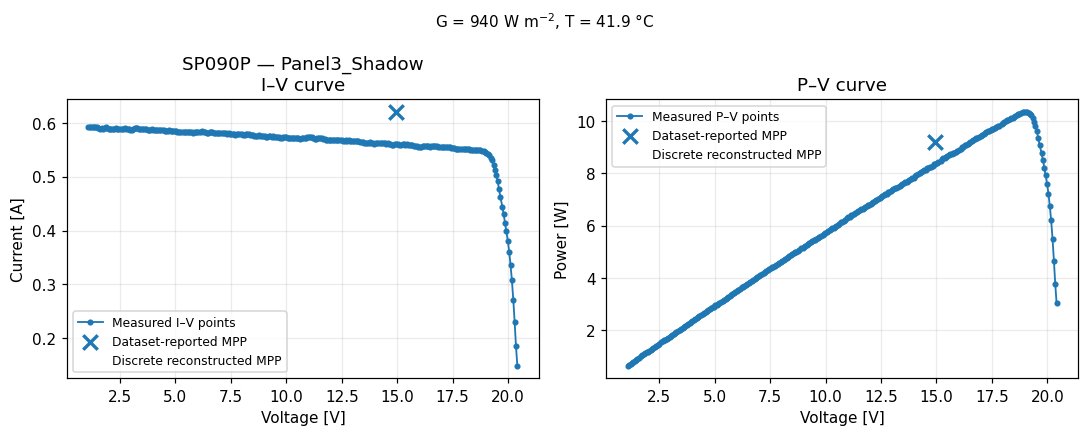


Trace summary
------------------------------------------------------------
Panel: SP090P
Trace: Panel3_Shadow
Condition: Shaded
Dataset-reported MPP: 9.2200 W, 14.9400 V, 0.6200 A
Discrete reconstructed MPP: 10.3498 W, 18.9523 V, 0.5461 A


In [16]:
# Inspect the single trace with MPP validation failure

failure_rows = df.loc[
    (
        ~df["Pmpp_validation_pass"]
        | ~df["Vmpp_validation_pass"]
        | ~df["Impp_validation_pass"]
    )
].copy()

print("Number of MPP-related validation failures:", len(failure_rows))

for _, row in failure_rows.iterrows():

    trace_key = row["trace_key"]

    if trace_key not in curve_store:
        raise KeyError(
            f"Trace key '{trace_key}' was not found in curve_store."
        )

    curve = curve_store[trace_key]

    voltage = np.asarray(
        curve["voltage_V"],
        dtype=float,
    )

    current = np.asarray(
        curve["current_A"],
        dtype=float,
    )

    power = np.asarray(
        curve["power_W"],
        dtype=float,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4),
    )

    # -------------------------------------------------------------
    # I–V curve
    # -------------------------------------------------------------

    axes[0].plot(
        voltage,
        current,
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Measured I–V points",
    )

    axes[0].scatter(
        row["Vmpp_reported_V"],
        row["Impp_reported_A"],
        s=90,
        marker="x",
        linewidth=2.2,
        label="Dataset-reported MPP",
        zorder=5,
    )

    axes[0].scatter(
        row["Vmpp_reconstructed_V"],
        row["Impp_reconstructed_A"],
        s=85,
        marker="o",
        facecolors="none",
        linewidth=2.0,
        label="Discrete reconstructed MPP",
        zorder=5,
    )

    axes[0].set_xlabel("Voltage [V]")
    axes[0].set_ylabel("Current [A]")

    axes[0].set_title(
        f"{row['panel']} — {row['trace']}\n"
        "I–V curve"
    )

    axes[0].legend(
        fontsize=8,
    )

    # -------------------------------------------------------------
    # P–V curve
    # -------------------------------------------------------------

    axes[1].plot(
        voltage,
        power,
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Measured P–V points",
    )

    axes[1].scatter(
        row["Vmpp_reported_V"],
        row["Pmpp_reported_W"],
        s=90,
        marker="x",
        linewidth=2.2,
        label="Dataset-reported MPP",
        zorder=5,
    )

    axes[1].scatter(
        row["Vmpp_reconstructed_V"],
        row["Pmpp_reconstructed_W"],
        s=85,
        marker="o",
        facecolors="none",
        linewidth=2.0,
        label="Discrete reconstructed MPP",
        zorder=5,
    )

    axes[1].set_xlabel("Voltage [V]")
    axes[1].set_ylabel("Power [W]")

    axes[1].set_title(
        "P–V curve"
    )

    axes[1].legend(
        fontsize=8,
    )

    fig.suptitle(
        f"G = {row['G_Wm2']:.0f} W m$^{{-2}}$, "
        f"T = {row['T_C']:.1f} °C",
        fontsize=10,
    )

    fig.tight_layout()
    plt.show()

    print("\nTrace summary")
    print("-" * 60)
    print("Panel:", row["panel"])
    print("Trace:", row["trace"])
    print("Condition:", row["condition"])
    print(
        "Dataset-reported MPP:",
        f"{row['Pmpp_reported_W']:.4f} W,",
        f"{row['Vmpp_reported_V']:.4f} V,",
        f"{row['Impp_reported_A']:.4f} A",
    )
    print(
        "Discrete reconstructed MPP:",
        f"{row['Pmpp_reconstructed_W']:.4f} W,",
        f"{row['Vmpp_reconstructed_V']:.4f} V,",
        f"{row['Impp_reconstructed_A']:.4f} A",
    )

In [17]:
# ================================================================
# 6A. Physical and curve-consistency audit of selected MPP metrics
# ================================================================

# Relative tolerances used only to determine whether dataset-reported
# MPP quantities are credible for primary analysis.
MPP_PRODUCT_TOLERANCE_PCT = 3.0
MPP_CURVE_POWER_TOLERANCE_PCT = 5.0
MPP_CURRENT_LIMIT_TOLERANCE_PCT = 2.0
MPP_VOLTAGE_LIMIT_TOLERANCE_PCT = 2.0


def evaluate_reported_mpp_consistency(
    row: pd.Series,
) -> dict:
    """
    Evaluate whether the dataset-reported MPP is physically consistent
    and sufficiently close to the stored I–V curve.

    The reported MPP passes only when:

    1. Impp does not materially exceed Isc.
    2. Vmpp does not materially exceed Voc.
    3. Pmpp agrees with Vmpp × Impp.
    4. The reported power is reasonably close to the maximum power
       reconstructed from the stored I–V vectors.
    """

    isc = float(row["Isc_reported_A"])
    voc = float(row["Voc_reported_V"])
    pmpp = float(row["Pmpp_reported_W"])
    vmpp = float(row["Vmpp_reported_V"])
    impp = float(row["Impp_reported_A"])

    pmpp_reconstructed = float(
        row["Pmpp_reconstructed_W"]
    )

    # ------------------------------------------------------------
    # Check 1: Impp should not exceed Isc
    # ------------------------------------------------------------

    impp_limit = isc * (
        1.0
        + MPP_CURRENT_LIMIT_TOLERANCE_PCT / 100.0
    )

    current_consistent = (
        np.isfinite(impp)
        and np.isfinite(isc)
        and impp <= impp_limit
    )

    # ------------------------------------------------------------
    # Check 2: Vmpp should not exceed Voc
    # ------------------------------------------------------------

    vmpp_limit = voc * (
        1.0
        + MPP_VOLTAGE_LIMIT_TOLERANCE_PCT / 100.0
    )

    voltage_consistent = (
        np.isfinite(vmpp)
        and np.isfinite(voc)
        and vmpp <= vmpp_limit
    )

    # ------------------------------------------------------------
    # Check 3: Reported Pmpp should agree with Vmpp × Impp
    # ------------------------------------------------------------

    pmpp_from_reported_mpp = vmpp * impp

    if (
        np.isfinite(pmpp)
        and pmpp > 0
        and np.isfinite(pmpp_from_reported_mpp)
    ):
        product_error_pct = (
            100.0
            * abs(
                pmpp
                - pmpp_from_reported_mpp
            )
            / pmpp
        )
    else:
        product_error_pct = np.nan

    product_consistent = (
        np.isfinite(product_error_pct)
        and product_error_pct
        <= MPP_PRODUCT_TOLERANCE_PCT
    )

    # ------------------------------------------------------------
    # Check 4: Reported Pmpp should be near the measured-curve maximum
    # ------------------------------------------------------------

    if (
        np.isfinite(pmpp)
        and pmpp > 0
        and np.isfinite(pmpp_reconstructed)
    ):
        curve_power_error_pct = (
            100.0
            * abs(
                pmpp
                - pmpp_reconstructed
            )
            / pmpp
        )
    else:
        curve_power_error_pct = np.nan

    curve_power_consistent = (
        np.isfinite(curve_power_error_pct)
        and curve_power_error_pct
        <= MPP_CURVE_POWER_TOLERANCE_PCT
    )

    all_consistent = (
        current_consistent
        and voltage_consistent
        and product_consistent
        and curve_power_consistent
    )

    failure_reasons = []

    if not current_consistent:
        failure_reasons.append(
            "reported Impp exceeds reported Isc"
        )

    if not voltage_consistent:
        failure_reasons.append(
            "reported Vmpp exceeds reported Voc"
        )

    if not product_consistent:
        failure_reasons.append(
            "reported Pmpp differs from Vmpp × Impp"
        )

    if not curve_power_consistent:
        failure_reasons.append(
            "reported Pmpp differs from measured-curve maximum"
        )

    return {
        "reported_mpp_consistent": all_consistent,
        "reported_mpp_failure_reason": (
            "; ".join(failure_reasons)
            if failure_reasons
            else ""
        ),
        "reported_pmpp_from_vmpp_impp_W": (
            pmpp_from_reported_mpp
        ),
        "reported_mpp_product_error_pct": (
            product_error_pct
        ),
        "reported_vs_curve_pmpp_error_pct": (
            curve_power_error_pct
        ),
        "reported_impp_exceeds_isc": (
            not current_consistent
        ),
        "reported_vmpp_exceeds_voc": (
            not voltage_consistent
        ),
    }


# Apply the audit to every trace.
mpp_audit = df.apply(
    evaluate_reported_mpp_consistency,
    axis=1,
    result_type="expand",
)

for column in mpp_audit.columns:
    df[column] = mpp_audit[column]


# ================================================================
# Select primary MPP quantities using the audit result
# ================================================================

# Isc and Voc remain dataset-reported when available because they
# passed the endpoint validation for all 17 traces.
df["Isc_A"] = df["Isc_reported_A"]
df["Voc_V"] = df["Voc_reported_V"]

df["Isc_source"] = "dataset_reported"
df["Voc_source"] = "dataset_reported"


# For MPP quantities, use reported values only when they pass all
# physical and curve-consistency checks.
reported_mpp_ok = df["reported_mpp_consistent"]

df["Pmpp_W"] = np.where(
    reported_mpp_ok,
    df["Pmpp_reported_W"],
    df["Pmpp_reconstructed_W"],
)

df["Vmpp_V"] = np.where(
    reported_mpp_ok,
    df["Vmpp_reported_V"],
    df["Vmpp_reconstructed_V"],
)

df["Impp_A"] = np.where(
    reported_mpp_ok,
    df["Impp_reported_A"],
    df["Impp_reconstructed_A"],
)

df["Pmpp_source"] = np.where(
    reported_mpp_ok,
    "dataset_reported",
    "reconstructed_after_consistency_failure",
)

df["Vmpp_source"] = np.where(
    reported_mpp_ok,
    "dataset_reported",
    "reconstructed_after_consistency_failure",
)

df["Impp_source"] = np.where(
    reported_mpp_ok,
    "dataset_reported",
    "reconstructed_after_consistency_failure",
)


# Recalculate FF from the final selected quantities.
df["FF"] = (
    df["Pmpp_W"]
    / (
        df["Voc_V"]
        * df["Isc_A"]
    )
)


# Recalculate selected MPP product consistency.
df["Pmpp_from_selected_mpp_W"] = (
    df["Vmpp_V"]
    * df["Impp_A"]
)

df["Pmpp_mpp_consistency_pct"] = (
    100.0
    * abs(
        df["Pmpp_W"]
        - df["Pmpp_from_selected_mpp_W"]
    )
    / df["Pmpp_W"]
)


# ================================================================
# Export and display audit results
# ================================================================

mpp_audit_columns = [
    "panel",
    "trace",
    "condition",
    "G_Wm2",
    "T_C",
    "Isc_reported_A",
    "Voc_reported_V",
    "Pmpp_reported_W",
    "Vmpp_reported_V",
    "Impp_reported_A",
    "Pmpp_reconstructed_W",
    "Vmpp_reconstructed_V",
    "Impp_reconstructed_A",
    "reported_mpp_consistent",
    "reported_mpp_failure_reason",
    "reported_mpp_product_error_pct",
    "reported_vs_curve_pmpp_error_pct",
    "reported_impp_exceeds_isc",
    "reported_vmpp_exceeds_voc",
    "Pmpp_W",
    "Vmpp_V",
    "Impp_A",
    "FF",
    "Pmpp_source",
    "Vmpp_source",
    "Impp_source",
]

mpp_audit_table = df[
    mpp_audit_columns
].copy()

mpp_audit_table.to_csv(
    TABLE_DIR / "mpp_consistency_audit.csv",
    index=False,
)


print("MPP consistency audit:")
print(
    df[
        [
            "panel",
            "trace",
            "condition",
            "reported_mpp_consistent",
            "reported_mpp_failure_reason",
            "Pmpp_source",
        ]
    ].to_string(
        index=False
    )
)

print("\nMPP source counts:")
print(
    df["Pmpp_source"].value_counts(
        dropna=False
    )
)

print("\nTraces requiring reconstructed MPP values:")
print(
    df.loc[
        ~df["reported_mpp_consistent"],
        [
            "panel",
            "trace",
            "condition",
            "reported_mpp_failure_reason",
            "Pmpp_reported_W",
            "Pmpp_reconstructed_W",
            "Vmpp_reported_V",
            "Vmpp_reconstructed_V",
            "Impp_reported_A",
            "Impp_reconstructed_A",
        ],
    ].to_string(
        index=False
    )
)

MPP consistency audit:
   panel         trace condition  reported_mpp_consistent                                                           reported_mpp_failure_reason                             Pmpp_source
M5_30112  PanelA_Clean     Clean                     True                                                                                                              dataset_reported
M5_30112  PanelB_Clean     Clean                     True                                                                                                              dataset_reported
M5_30112  PanelC_Clean     Clean                     True                                                                                                              dataset_reported
M5_30112 PanelA_Shadow    Shaded                     True                                                                                                              dataset_reported
M5_30112 PanelB_Shadow    Shaded                     True

In [18]:
# Recheck final selected MPP quantities after the audit correction

if not df["FF"].between(0, 1).all():
    invalid = df.loc[
        ~df["FF"].between(0, 1),
        [
            "panel",
            "trace",
            "condition",
            "FF",
            "Pmpp_W",
            "Voc_V",
            "Isc_A",
        ],
    ]

    raise AssertionError(
        "One or more final fill-factor values are outside 0–1:\n\n"
        + invalid.to_string(index=False)
    )

if (df["Pmpp_mpp_consistency_pct"] > 3.0).any():
    invalid = df.loc[
        df["Pmpp_mpp_consistency_pct"] > 3.0,
        [
            "panel",
            "trace",
            "condition",
            "Pmpp_W",
            "Vmpp_V",
            "Impp_A",
            "Pmpp_from_selected_mpp_W",
            "Pmpp_mpp_consistency_pct",
            "Pmpp_source",
        ],
    ]

    raise AssertionError(
        "Final selected MPP quantities remain inconsistent:\n\n"
        + invalid.to_string(index=False)
    )

print("Post-audit MPP integrity checks passed.")

print("\nFinal MPP source counts:")
print(df["Pmpp_source"].value_counts())

print(
    "\nMaximum final Pmpp versus Vmpp × Impp discrepancy:",
    f"{df['Pmpp_mpp_consistency_pct'].max():.4f}%",
)

Post-audit MPP integrity checks passed.

Final MPP source counts:
Pmpp_source
dataset_reported                           16
reconstructed_after_consistency_failure     1
Name: count, dtype: int64

Maximum final Pmpp versus Vmpp × Impp discrepancy: 1.3499%


## 7. Revised clean references and normalized metrics

In [20]:
# ================================================================
# 7. Factor-consistent clean references and normalized metrics
# ================================================================

def require_clean_median(
    panel_data: pd.DataFrame,
    column: str,
    panel: str,
) -> float:
    """
    Return the within-module clean median for a required variable.

    The analysis stops if no valid clean observations are available.
    """
    clean_values = panel_data.loc[
        panel_data["condition"] == "Clean",
        column,
    ].dropna()

    if clean_values.empty:
        raise RuntimeError(
            f"No valid clean observations are available for "
            f"panel '{panel}', variable '{column}'."
        )

    return float(clean_values.median())


# ---------------------------------------------------------------------
# Primary irradiance-normalized quantities
# ---------------------------------------------------------------------

df["Phi_m2"] = (
    df["Pmpp_W"]
    / df["G_Wm2"]
)

df["Isc_per_G"] = (
    df["Isc_A"]
    / df["G_Wm2"]
)


# ---------------------------------------------------------------------
# Initialize normalized variables
# ---------------------------------------------------------------------

normalized_columns = [
    "R_P",
    "R_I_G",
    "R_I_original",
    "R_V",
    "R_FF",
]

for column in normalized_columns:
    df[column] = np.nan


# ---------------------------------------------------------------------
# Construct factor-consistent clean references
# ---------------------------------------------------------------------

reference_rows = []

for panel in sorted(
    df["panel"].unique()
):
    panel_mask = (
        df["panel"] == panel
    )

    panel_data = df.loc[
        panel_mask
    ].copy()

    clean_mask = (
        panel_data["condition"] == "Clean"
    )

    n_clean = int(
        clean_mask.sum()
    )

    if n_clean == 0:
        raise RuntimeError(
            f"No clean traces are available for {panel}."
        )

    # Independent clean medians for the physical factors.
    isc_per_g_ref = require_clean_median(
        panel_data=panel_data,
        column="Isc_per_G",
        panel=panel,
    )

    isc_ref_original = require_clean_median(
        panel_data=panel_data,
        column="Isc_A",
        panel=panel,
    )

    voc_ref = require_clean_median(
        panel_data=panel_data,
        column="Voc_V",
        panel=panel,
    )

    ff_ref = require_clean_median(
        panel_data=panel_data,
        column="FF",
        panel=panel,
    )

    # Direct median Phi is retained only as a diagnostic comparison.
    phi_ref_direct_median = require_clean_median(
        panel_data=panel_data,
        column="Phi_m2",
        panel=panel,
    )

    # Factor-consistent synthetic clean reference.
    phi_ref_factor_consistent = (
        isc_per_g_ref
        * voc_ref
        * ff_ref
    )

    if phi_ref_factor_consistent <= 0:
        raise RuntimeError(
            f"Invalid factor-consistent Phi reference for {panel}: "
            f"{phi_ref_factor_consistent}"
        )

    # -------------------------------------------------------------
    # Normalized quantities
    # -------------------------------------------------------------

    df.loc[
        panel_mask,
        "R_P",
    ] = (
        df.loc[
            panel_mask,
            "Phi_m2",
        ]
        / phi_ref_factor_consistent
    )

    df.loc[
        panel_mask,
        "R_I_G",
    ] = (
        df.loc[
            panel_mask,
            "Isc_per_G",
        ]
        / isc_per_g_ref
    )

    # Original non-irradiance-normalized index retained for comparison.
    df.loc[
        panel_mask,
        "R_I_original",
    ] = (
        df.loc[
            panel_mask,
            "Isc_A",
        ]
        / isc_ref_original
    )

    df.loc[
        panel_mask,
        "R_V",
    ] = (
        df.loc[
            panel_mask,
            "Voc_V",
        ]
        / voc_ref
    )

    df.loc[
        panel_mask,
        "R_FF",
    ] = (
        df.loc[
            panel_mask,
            "FF",
        ]
        / ff_ref
    )

    reference_difference_pct = (
        100.0
        * abs(
            phi_ref_direct_median
            - phi_ref_factor_consistent
        )
        / phi_ref_direct_median
    )

    reference_rows.append(
        {
            "panel": panel,
            "reference_method": (
                "within-module clean medians; "
                "factor-consistent Phi reference"
            ),
            "Phi_ref_direct_median_m2": (
                phi_ref_direct_median
            ),
            "Phi_ref_factor_consistent_m2": (
                phi_ref_factor_consistent
            ),
            "Phi_reference_difference_pct": (
                reference_difference_pct
            ),
            "Isc_per_G_ref": isc_per_g_ref,
            "Isc_ref_A": isc_ref_original,
            "Voc_ref_V": voc_ref,
            "FF_ref": ff_ref,
            "n_clean": n_clean,
        }
    )


references = pd.DataFrame(
    reference_rows
)


# ---------------------------------------------------------------------
# Verify exact factor decomposition
# ---------------------------------------------------------------------

df["R_P_factor_product"] = (
    df["R_I_G"]
    * df["R_V"]
    * df["R_FF"]
)

df["factor_product_abs_error"] = (
    df["R_P"]
    - df["R_P_factor_product"]
).abs()

df["factor_product_error_pct"] = (
    100.0
    * df["factor_product_abs_error"]
    / df["R_P"].abs().replace(
        0,
        np.nan,
    )
)


# ---------------------------------------------------------------------
# Hard consistency check
# ---------------------------------------------------------------------

MAX_ALLOWED_PRODUCT_ERROR_PCT = 1e-8

factor_failures = df.loc[
    df["factor_product_error_pct"]
    > MAX_ALLOWED_PRODUCT_ERROR_PCT,
    [
        "panel",
        "trace",
        "condition",
        "R_P",
        "R_I_G",
        "R_V",
        "R_FF",
        "R_P_factor_product",
        "factor_product_error_pct",
    ],
]

if not factor_failures.empty:
    raise AssertionError(
        "The factor decomposition is not numerically exact:\n\n"
        + factor_failures.to_string(
            index=False
        )
    )


# ---------------------------------------------------------------------
# Export and display
# ---------------------------------------------------------------------

references.to_csv(
    TABLE_DIR / "clean_references.csv",
    index=False,
)

factor_check_columns = [
    "panel",
    "trace",
    "condition",
    "R_P",
    "R_I_G",
    "R_V",
    "R_FF",
    "R_P_factor_product",
    "factor_product_abs_error",
    "factor_product_error_pct",
]

df[
    factor_check_columns
].to_csv(
    TABLE_DIR / "factor_decomposition_check.csv",
    index=False,
)


print("Factor-consistent clean references:")
print(
    references.to_string(
        index=False
    )
)

print(
    "\nMaximum factor-product discrepancy:",
    f"{df['factor_product_error_pct'].max():.12e}%",
)

print(
    "\nIdentity verified:"
    "\nR_P = R_I_G × R_V × R_FF"
)

Factor-consistent clean references:
   panel                                             reference_method  Phi_ref_direct_median_m2  Phi_ref_factor_consistent_m2  Phi_reference_difference_pct  Isc_per_G_ref  Isc_ref_A  Voc_ref_V   FF_ref  n_clean
M5_30112 within-module clean medians; factor-consistent Phi reference                  0.024678                      0.024774                      0.391034       0.001916    1.76255      21.06 0.613929        3
  SP090P within-module clean medians; factor-consistent Phi reference                  0.077278                      0.076189                      1.408451       0.005365    5.02541      21.00 0.676293        3

Maximum factor-product discrepancy: 4.124638674573e-14%

Identity verified:
R_P = R_I_G × R_V × R_FF


## 8. Logarithmic current–voltage–FF decomposition

In [21]:
for src,dst in [("R_P","ln_R_P"),("R_I_G","ln_R_I_G"),("R_V","ln_R_V"),("R_FF","ln_R_FF")]:
    df[dst]=np.where(df[src]>0,np.log(df[src]),np.nan)
df["ln_factor_sum"]=df.ln_R_I_G+df.ln_R_V+df.ln_R_FF
df["ln_decomposition_residual"]=df.ln_R_P-df.ln_factor_sum
den=df.ln_R_I_G.abs()+df.ln_R_V.abs()+df.ln_R_FF.abs()
df["current_log_share"]=df.ln_R_I_G.abs()/den; df["voltage_log_share"]=df.ln_R_V.abs()/den; df["ff_log_share"]=df.ln_R_FF.abs()/den
decomp=(df.groupby(["panel","condition"],observed=False).agg(n=("trace","size"),R_P_median=("R_P","median"),R_I_G_median=("R_I_G","median"),
        R_V_median=("R_V","median"),R_FF_median=("R_FF","median"),current_log_share_median=("current_log_share","median"),
        voltage_log_share_median=("voltage_log_share","median"),ff_log_share_median=("ff_log_share","median")).reset_index())
decomp.to_csv(TABLE_DIR/"power_loss_decomposition_summary.csv",index=False)
print(decomp.to_string(index=False))

   panel condition  n  R_P_median  R_I_G_median  R_V_median  R_FF_median  current_log_share_median  voltage_log_share_median  ff_log_share_median
M5_30112     Clean  3    0.996105      1.000000    1.000000     1.000000                  0.067941                  0.288167             0.643892
M5_30112    Shaded  3    0.267571      0.236732    0.973409     1.302540                  0.858050                  0.016665             0.140434
M5_30112    Soiled  3    0.978519      0.976822    1.007597     0.994185                  0.636362                  0.205378             0.158259
  SP090P     Clean  3    1.014286      1.000000    1.000000     1.000000                  0.062170                  0.216205             0.721625
  SP090P    Shaded  2    0.157238      0.127863    0.973810     1.262686                  0.887743                  0.011546             0.100712
  SP090P    Soiled  3    1.042016      0.975102    1.028571     1.016337                  0.202836                  0.252660

## 9. Unclipped condition summaries

In [22]:
condition_summary=(df.groupby(["panel","condition"],observed=False).agg(n=("trace","size"),G_mean_Wm2=("G_Wm2","mean"),G_min_Wm2=("G_Wm2","min"),G_max_Wm2=("G_Wm2","max"),
    T_mean_C=("T_C","mean"),T_min_C=("T_C","min"),T_max_C=("T_C","max"),R_P_mean=("R_P","mean"),R_P_median=("R_P","median"),R_P_min=("R_P","min"),R_P_max=("R_P","max"),
    R_I_G_mean=("R_I_G","mean"),R_I_G_median=("R_I_G","median"),FF_mean=("FF","mean"),FF_min=("FF","min"),FF_max=("FF","max")).reset_index())
condition_summary.to_csv(TABLE_DIR/"condition_summary.csv",index=False)
loss=[]
for panel in sorted(df.panel.unique()):
    s=condition_summary[condition_summary.panel==panel]; clean=float(s.loc[s.condition=="Clean","R_P_mean"].iloc[0])
    for cond in ["Soiled","Shaded"]:
        val=float(s.loc[s.condition==cond,"R_P_mean"].iloc[0]); loss.append({"panel":panel,"condition":cond,"clean_R_P_mean":clean,"condition_R_P_mean":val,"relative_reduction_pct":100*(1-val/clean)})
relative_losses=pd.DataFrame(loss); relative_losses.to_csv(TABLE_DIR/"relative_power_reductions.csv",index=False)
print(condition_summary.to_string(index=False)); print(relative_losses.to_string(index=False))

   panel condition  n  G_mean_Wm2  G_min_Wm2  G_max_Wm2  T_mean_C  T_min_C  T_max_C  R_P_mean  R_P_median  R_P_min  R_P_max  R_I_G_mean  R_I_G_median  FF_mean   FF_min   FF_max
M5_30112     Clean  3  919.333333      900.0      948.0 38.966667     34.2     42.6  1.019633    0.996105 0.993357 1.069436    1.000272      1.000000 0.634551 0.609850 0.679873
M5_30112    Shaded  3  934.666667      900.0      970.0 40.166667     37.9     42.7  0.275852    0.267571 0.258332 0.301653    0.226230      0.236732 0.777066 0.712860 0.818672
M5_30112    Soiled  3  946.666667      900.0      990.0 39.033333     37.4     40.3  0.974478    0.978519 0.899026 1.045888    0.961019      0.976822 0.632505 0.608948 0.678208
  SP090P     Clean  3  934.333333      920.0      950.0 39.733333     39.3     40.3  0.939297    1.014286 0.771963 1.031643    1.001539      1.000000 0.643411 0.546392 0.707547
  SP090P    Shaded  2  943.000000      940.0      946.0 41.650000     41.4     41.9  0.157238    0.157238 0.144515 

In [23]:
condition_summary_extended = (
    df.groupby(
        ["panel", "condition"],
        observed=False,
    )
    .agg(
        n=("trace", "size"),

        R_P_mean=("R_P", "mean"),
        R_P_median=("R_P", "median"),

        R_I_G_mean=("R_I_G", "mean"),
        R_I_G_median=("R_I_G", "median"),

        R_V_mean=("R_V", "mean"),
        R_V_median=("R_V", "median"),

        R_FF_mean=("R_FF", "mean"),
        R_FF_median=("R_FF", "median"),

        FF_absolute_mean=("FF", "mean"),
        FF_absolute_median=("FF", "median"),
    )
    .reset_index()
)

condition_summary_extended.to_csv(
    TABLE_DIR / "condition_summary_extended.csv",
    index=False,
)

print(condition_summary_extended.to_string(index=False))

   panel condition  n  R_P_mean  R_P_median  R_I_G_mean  R_I_G_median  R_V_mean  R_V_median  R_FF_mean  R_FF_median  FF_absolute_mean  FF_absolute_median
M5_30112     Clean  3  1.019633    0.996105    1.000272      1.000000  0.987179    1.000000   1.033590     1.000000          0.634551            0.613929
M5_30112    Shaded  3  0.275852    0.267571    0.226230      0.236732  0.967078    0.973409   1.265728     1.302540          0.777066            0.799667
M5_30112    Soiled  3  0.974478    0.978519    0.961019      0.976822  0.985438    1.007597   1.030258     0.994185          0.632505            0.610359
  SP090P     Clean  3  0.939297    1.014286    1.001539      1.000000  0.984127    1.000000   0.951378     1.000000          0.643411            0.676293
  SP090P    Shaded  2  0.157238    0.157238    0.127863      0.127863  0.973810    0.973810   1.262686     1.262686          0.853946            0.853946
  SP090P    Soiled  3  0.749052    1.042016    0.709837      0.975102  0.966

## 10. Regression, bootstrap intervals, leave-one-out, and module interaction

In [24]:
def regression(data,xcol,ycol):
    s=data[[xcol,ycol]].dropna(); x=s[xcol].to_numpy(float); y=s[ycol].to_numpy(float)
    if len(s)<3 or np.unique(x).size<2: return {k:np.nan for k in ["pearson_r","pearson_p","spearman_rho","spearman_p","slope","intercept","R2","rmse"]}|{"n":len(s)}
    pr,pp=stats.pearsonr(x,y); sr,sp=stats.spearmanr(x,y); fit=stats.linregress(x,y); yh=fit.intercept+fit.slope*x
    ssr=np.sum((y-yh)**2); sst=np.sum((y-y.mean())**2)
    return {"n":len(s),"pearson_r":pr,"pearson_p":pp,"spearman_rho":sr,"spearman_p":sp,"slope":fit.slope,"intercept":fit.intercept,"R2":1-ssr/sst,"rmse":np.sqrt(np.mean((y-yh)**2))}

def bootstrap_ci(data,xcol,ycol,n_boot=5000,seed=RANDOM_SEED):
    s=data[[xcol,ycol]].dropna().reset_index(drop=True); rng=np.random.default_rng(seed); slopes=[]; rs=[]
    for _ in range(n_boot):
        b=s.iloc[rng.integers(0,len(s),len(s))]; x=b[xcol].to_numpy(float); y=b[ycol].to_numpy(float)
        if np.unique(x).size<2: continue
        slopes.append(stats.linregress(x,y).slope); rs.append(stats.pearsonr(x,y)[0])
    return {"slope_ci_low":np.percentile(slopes,2.5),"slope_ci_high":np.percentile(slopes,97.5),"pearson_r_ci_low":np.percentile(rs,2.5),"pearson_r_ci_high":np.percentile(rs,97.5),"n_boot_valid":len(slopes)}

rows=[]
for panel in sorted(df.panel.unique()): rows.append({"group":panel,"index":PRIMARY_INDEX,**regression(df[df.panel==panel],PRIMARY_INDEX,"R_P"),**bootstrap_ci(df[df.panel==panel],PRIMARY_INDEX,"R_P")})
rows.append({"group":"All panels","index":PRIMARY_INDEX,**regression(df,PRIMARY_INDEX,"R_P"),**bootstrap_ci(df,PRIMARY_INDEX,"R_P")})
rows.append({"group":"All panels","index":"R_I_original",**regression(df,"R_I_original","R_P"),**bootstrap_ci(df,"R_I_original","R_P")})
regression_table=pd.DataFrame(rows); regression_table.to_csv(TABLE_DIR/"regression_summary.csv",index=False)

loo=[]
for idx,r in df.iterrows(): loo.append({"omitted_panel":r.panel,"omitted_trace":r.trace,**regression(df.drop(index=idx),PRIMARY_INDEX,"R_P")})
pd.DataFrame(loo).to_csv(TABLE_DIR/"leave_one_trace_out.csv",index=False)

mods=sorted(df.panel.unique()); ref,comp=mods; m=df[[PRIMARY_INDEX,"R_P","panel"]].dropna().copy(); m["module"]=(m.panel==comp).astype(float); m["interaction"]=m[PRIMARY_INDEX]*m.module
X=np.column_stack([np.ones(len(m)),m[PRIMARY_INDEX],m.module,m.interaction]); y=m.R_P.to_numpy(float); beta=np.linalg.lstsq(X,y,rcond=None)[0]; resid=y-X@beta
n,p=X.shape; sigma2=np.sum(resid**2)/(n-p); cov=sigma2*np.linalg.inv(X.T@X); se=np.sqrt(np.diag(cov)); tv=beta/se; pv=2*stats.t.sf(np.abs(tv),df=n-p)
interaction_table=pd.DataFrame({"term":["Intercept",PRIMARY_INDEX,f"{comp} indicator",f"{PRIMARY_INDEX} x {comp}"],"estimate":beta,"std_error":se,"t_value":tv,"p_value":pv})
interaction_table.to_csv(TABLE_DIR/"module_interaction_model.csv",index=False)
print(regression_table.to_string(index=False)); print(interaction_table.to_string(index=False))

     group        index  n  pearson_r    pearson_p  spearman_rho  spearman_p    slope  intercept       R2     rmse  slope_ci_low  slope_ci_high  pearson_r_ci_low  pearson_r_ci_high  n_boot_valid
  M5_30112        R_I_G  9   0.998142 9.092159e-10      0.983333    0.000002 0.958285   0.057898 0.996287 0.020902      0.924404       1.026668          0.984553           0.999913          5000
    SP090P        R_I_G  8   0.972247 5.233337e-05      0.523810    0.182721 0.968761   0.019755 0.945265 0.097271      0.771126       1.079615          0.871465           0.999522          5000
All panels        R_I_G 17   0.982927 1.929162e-12      0.750460    0.000519 0.966854   0.037245 0.966146 0.070160      0.882294       1.030744          0.943463           0.998684          5000
All panels R_I_original 17   0.983733 1.345746e-12      0.751686    0.000502 0.960862   0.034884 0.967730 0.068499      0.884494       1.022714          0.950783           0.997655          5000
            term  estimat

## 11. Descriptive threshold analysis and electrical-state labels

In [25]:
thresholds=np.linspace(0,1.2,241)
def frac(arr,t):
    arr=np.asarray(arr,float); arr=arr[np.isfinite(arr)]; return np.mean(arr<t) if len(arr) else np.nan
threshold_table=pd.DataFrame({"threshold":thresholds,
    "shaded_below_fraction":[frac(df.loc[df.condition=="Shaded",PRIMARY_INDEX],t) for t in thresholds],
    "clean_below_fraction":[frac(df.loc[df.condition=="Clean",PRIMARY_INDEX],t) for t in thresholds],
    "soiled_below_fraction":[frac(df.loc[df.condition=="Soiled",PRIMARY_INDEX],t) for t in thresholds]})
threshold_table.to_csv(TABLE_DIR/"threshold_sensitivity.csv",index=False)
mx=float(df.loc[df.condition=="Shaded",PRIMARY_INDEX].max()); mn=float(df.loc[df.condition=="Clean",PRIMARY_INDEX].min())
separation=pd.DataFrame([{"index":PRIMARY_INDEX,"max_shaded":mx,"min_clean":mn,"observed_gap_exists":mx<mn,
    "descriptive_separating_interval":f"({mx:.6f}, {mn:.6f}]" if mx<mn else "none","illustrative_threshold":ILLUSTRATIVE_THRESHOLD,
    "threshold_is_inside_gap":mx<ILLUSTRATIVE_THRESHOLD<=mn}])
separation.to_csv(TABLE_DIR/"observed_threshold_separation.csv",index=False)
df["electrical_state"]=np.where(df[PRIMARY_INDEX]<ILLUSTRATIVE_THRESHOLD,"Severe current-limited state","No severe current collapse")
print(separation.to_string(index=False)); print(pd.crosstab(df.condition,df.electrical_state))

index  max_shaded  min_clean  observed_gap_exists descriptive_separating_interval  illustrative_threshold  threshold_is_inside_gap
R_I_G    0.243062   0.986073                 True            (0.243062, 0.986073]                     0.5                     True
electrical_state  No severe current collapse  Severe current-limited state
condition                                                                 
Clean                                      6                             0
Shaded                                     0                             5
Soiled                                     5                             1


## 12. Reference-method sensitivity

In [26]:
methods={"median":np.nanmedian,"mean":np.nanmean,"maximum":np.nanmax,"P95":lambda x:np.nanpercentile(x,95)}; rows=[]
for panel in sorted(df.panel.unique()):
    sub=df[df.panel==panel].copy(); clean=sub[sub.condition=="Clean"]
    for name,fun in methods.items():
        pr=float(fun(clean.Phi_m2)); ir=float(fun(clean.Isc_per_G_A_m2_W)); sub["RPx"]=sub.Phi_m2/pr; sub["RIx"]=sub.Isc_per_G_A_m2_W/ir; st=regression(sub,"RIx","RPx")
        for cond in CONDITION_ORDER:
            q=sub[sub.condition==cond]; rows.append({"panel":panel,"reference_method":name,"condition":cond,"R_P_mean":q.RPx.mean(),"R_I_G_mean":q.RIx.mean(),"slope":st["slope"],"R2":st["R2"],"pearson_r":st["pearson_r"]})
reference_sensitivity=pd.DataFrame(rows); reference_sensitivity.to_csv(TABLE_DIR/"reference_method_sensitivity.csv",index=False)
print(reference_sensitivity.head(12).to_string(index=False))

   panel reference_method condition  R_P_mean  R_I_G_mean    slope       R2  pearson_r
M5_30112           median     Clean  1.023620    1.000272 0.962032 0.996287   0.998142
M5_30112           median    Soiled  0.978288    0.961019 0.962032 0.996287   0.998142
M5_30112           median    Shaded  0.276931    0.226230 0.962032 0.996287   0.998142
M5_30112             mean     Clean  1.000000    1.000000 0.940089 0.996287   0.998142
M5_30112             mean    Soiled  0.955714    0.960757 0.940089 0.996287   0.998142
M5_30112             mean    Shaded  0.270541    0.226169 0.940089 0.996287   0.998142
M5_30112          maximum     Clean  0.953430    0.989562 0.905764 0.996287   0.998142
M5_30112          maximum    Soiled  0.911207    0.950729 0.905764 0.996287   0.998142
M5_30112          maximum    Shaded  0.257942    0.223808 0.905764 0.996287   0.998142
M5_30112              P95     Clean  0.960013    0.990623 0.911041 0.996287   0.998142
M5_30112              P95    Soiled  0.9174

## 13. Figure helpers

In [27]:
def save_fig(fig,stem):
    fig.savefig(FIG_DIR/f"{stem}.png",dpi=SAVE_DPI,bbox_inches="tight"); fig.savefig(FIG_DIR/f"{stem}.pdf",bbox_inches="tight")

def median_trace(data,panel,condition,metric="R_P"):
    q=data[(data.panel==panel)&(data.condition==condition)&data[metric].notna()]
    if q.empty: raise RuntimeError(f"No {panel} {condition} traces")
    med=q[metric].median(); return q.loc[(q[metric]-med).abs().idxmin()]
markers={"Clean":"o","Soiled":"s","Shaded":"^"}; panels=sorted(df.panel.unique()); rng=np.random.default_rng(RANDOM_SEED)

## 14. Figure 1 — relative irradiance-normalized power

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig1_relative_power_by_condition.png
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig1_relative_power_by_condition.pdf


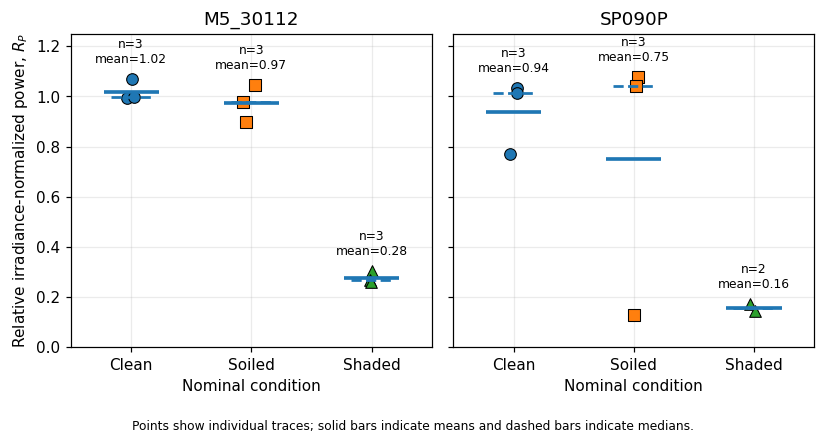

In [30]:
# ================================================================
# 14. Figure 1 — relative irradiance-normalized power
# ================================================================

# Define locally so this cell does not depend on a previously run
# figure-helper cell.
condition_markers = {
    "Clean": "o",
    "Soiled": "s",
    "Shaded": "^",
}

# Define the save helper locally if it is not already available.
if "save_figure" not in globals():

    def save_figure(
        fig: plt.Figure,
        filename_stem: str,
    ) -> None:
        png_path = FIG_DIR / f"{filename_stem}.png"
        pdf_path = FIG_DIR / f"{filename_stem}.pdf"

        fig.savefig(
            png_path,
            dpi=SAVE_DPI,
            bbox_inches="tight",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        print("Saved:", png_path)
        print("Saved:", pdf_path)


rng = np.random.default_rng(
    RANDOM_SEED
)

panel_order = sorted(
    df["panel"].unique()
)

fig, axes = plt.subplots(
    1,
    len(panel_order),
    figsize=(7.6, 4.0),
    sharey=True,
    squeeze=False,
)

# Leave enough vertical room for annotations.
overall_maximum = float(
    df["R_P"].max()
)

annotation_margin = max(
    0.045,
    0.05 * overall_maximum,
)

for ax, panel in zip(
    axes[0],
    panel_order,
):
    panel_data = df.loc[
        df["panel"] == panel
    ].copy()

    for condition_index, condition in enumerate(
        CONDITION_ORDER
    ):
        condition_values = (
            panel_data.loc[
                panel_data["condition"] == condition,
                "R_P",
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        if condition_values.size == 0:
            continue

        jitter = rng.normal(
            loc=0.0,
            scale=0.035,
            size=condition_values.size,
        )

        x_positions = (
            np.full(
                condition_values.size,
                condition_index,
                dtype=float,
            )
            + jitter
        )

        ax.scatter(
            x_positions,
            condition_values,
            marker=condition_markers.get(
                condition,
                "o",
            ),
            s=58,
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

        mean_value = float(
            np.mean(condition_values)
        )

        median_value = float(
            np.median(condition_values)
        )

        maximum_value = float(
            np.max(condition_values)
        )

        # Solid horizontal line: arithmetic mean.
        ax.hlines(
            y=mean_value,
            xmin=condition_index - 0.23,
            xmax=condition_index + 0.23,
            linewidth=2.4,
            zorder=4,
        )

        # Dashed horizontal line: median.
        ax.hlines(
            y=median_value,
            xmin=condition_index - 0.17,
            xmax=condition_index + 0.17,
            linewidth=1.8,
            linestyle="--",
            zorder=4,
        )

        annotation_text = (
            f"n={condition_values.size}\n"
            f"mean={mean_value:.2f}"
        )

        ax.text(
            condition_index,
            maximum_value + annotation_margin,
            annotation_text,
            horizontalalignment="center",
            verticalalignment="bottom",
            fontsize=8,
        )

    ax.set_title(
        panel
    )

    ax.set_xticks(
        range(len(CONDITION_ORDER))
    )

    ax.set_xticklabels(
        CONDITION_ORDER
    )

    ax.set_xlabel(
        "Nominal condition"
    )

    ax.set_xlim(
        -0.5,
        len(CONDITION_ORDER) - 0.5,
    )

    ax.set_ylim(
        bottom=0,
        top=overall_maximum + 3.2 * annotation_margin,
    )


axes[0, 0].set_ylabel(
    r"Relative irradiance-normalized power, $R_P$"
)

# Figure-level explanation avoids an unnecessary repeated legend.
fig.text(
    0.5,
    0.01,
    "Points show individual traces; solid bars indicate means "
    "and dashed bars indicate medians.",
    horizontalalignment="center",
    fontsize=8,
)

fig.tight_layout(
    rect=[0, 0.055, 1, 1]
)

save_figure(
    fig,
    "Fig1_relative_power_by_condition",
)

plt.show()

## 15. Figure 2 — revised current index versus normalized power

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig2_RIG_vs_RP.png
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig2_RIG_vs_RP.pdf


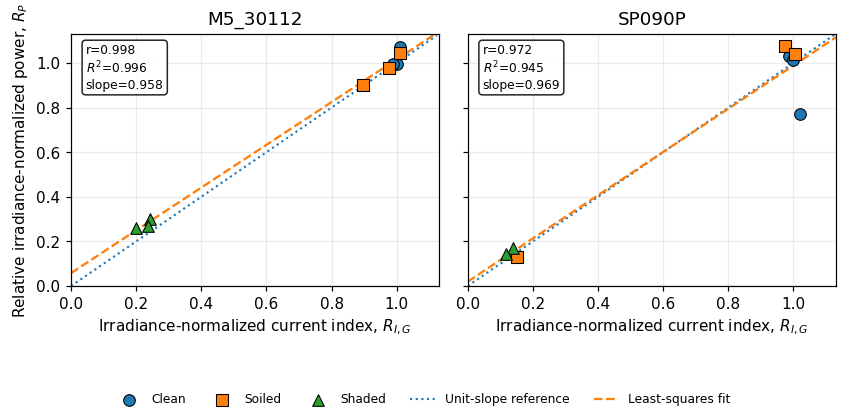

In [32]:
# ================================================================
# 15. Figure 2 — revised current index versus normalized power
# ================================================================

# Keep this cell self-contained.
condition_markers = {
    "Clean": "o",
    "Soiled": "s",
    "Shaded": "^",
}

if "save_figure" not in globals():

    def save_figure(
        fig: plt.Figure,
        filename_stem: str,
    ) -> None:
        png_path = FIG_DIR / f"{filename_stem}.png"
        pdf_path = FIG_DIR / f"{filename_stem}.pdf"

        fig.savefig(
            png_path,
            dpi=SAVE_DPI,
            bbox_inches="tight",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        print("Saved:", png_path)
        print("Saved:", pdf_path)


panel_order = sorted(
    df["panel"].unique()
)

fig, axes = plt.subplots(
    1,
    len(panel_order),
    figsize=(7.8, 3.8),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for ax, panel in zip(
    axes[0],
    panel_order,
):
    panel_data = df.loc[
        df["panel"] == panel
    ].copy()

    regression_row = regression_table.loc[
        (regression_table["group"] == panel)
        & (regression_table["index"] == PRIMARY_INDEX)
    ]

    if regression_row.empty:
        raise RuntimeError(
            f"No regression result was found for panel '{panel}' "
            f"and index '{PRIMARY_INDEX}'."
        )

    reg = regression_row.iloc[0]

    for condition in CONDITION_ORDER:
        points = panel_data.loc[
            panel_data["condition"] == condition
        ]

        if points.empty:
            continue

        ax.scatter(
            points[PRIMARY_INDEX],
            points["R_P"],
            marker=condition_markers.get(
                condition,
                "o",
            ),
            s=58,
            edgecolor="black",
            linewidth=0.7,
            label=condition,
            zorder=3,
        )

    upper_limit = max(
        1.10,
        float(
            panel_data[
                [
                    PRIMARY_INDEX,
                    "R_P",
                ]
            ].max().max()
        )
        * 1.05,
    )

    x_values = np.linspace(
        0.0,
        upper_limit,
        200,
    )

    # Unit-slope reference.
    ax.plot(
        x_values,
        x_values,
        linestyle=":",
        linewidth=1.4,
        label="Unit-slope reference",
        zorder=1,
    )

    # Module-specific least-squares fit.
    fitted_values = (
        float(reg["intercept"])
        + float(reg["slope"]) * x_values
    )

    ax.plot(
        x_values,
        fitted_values,
        linestyle="--",
        linewidth=1.5,
        label="Least-squares fit",
        zorder=2,
    )

    annotation_text = (
        f"r={float(reg['pearson_r']):.3f}\n"
        f"$R^2$={float(reg['R2']):.3f}\n"
        f"slope={float(reg['slope']):.3f}"
    )

    ax.text(
        0.04,
        0.96,
        annotation_text,
        transform=ax.transAxes,
        horizontalalignment="left",
        verticalalignment="top",
        fontsize=8,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

    ax.set_title(
        panel
    )

    ax.set_xlabel(
        r"Irradiance-normalized current index, $R_{I,G}$"
    )

    ax.set_xlim(
        0,
        upper_limit,
    )

    ax.set_ylim(
        0,
        upper_limit,
    )

axes[0, 0].set_ylabel(
    r"Relative irradiance-normalized power, $R_P$"
)

# Use one legend for the full figure.
handles, labels = axes[0, -1].get_legend_handles_labels()

# Remove duplicate entries while preserving order.
unique_legend = dict(
    zip(
        labels,
        handles,
    )
)

fig.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="lower center",
    ncol=5,
    fontsize=8,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0.14, 1, 1]
)

save_figure(
    fig,
    "Fig2_RIG_vs_RP",
)

plt.show()

## 16. Figure 3 — median clean and median shaded curves

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig3_median_clean_shaded_IV_PV.png
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig3_median_clean_shaded_IV_PV.pdf


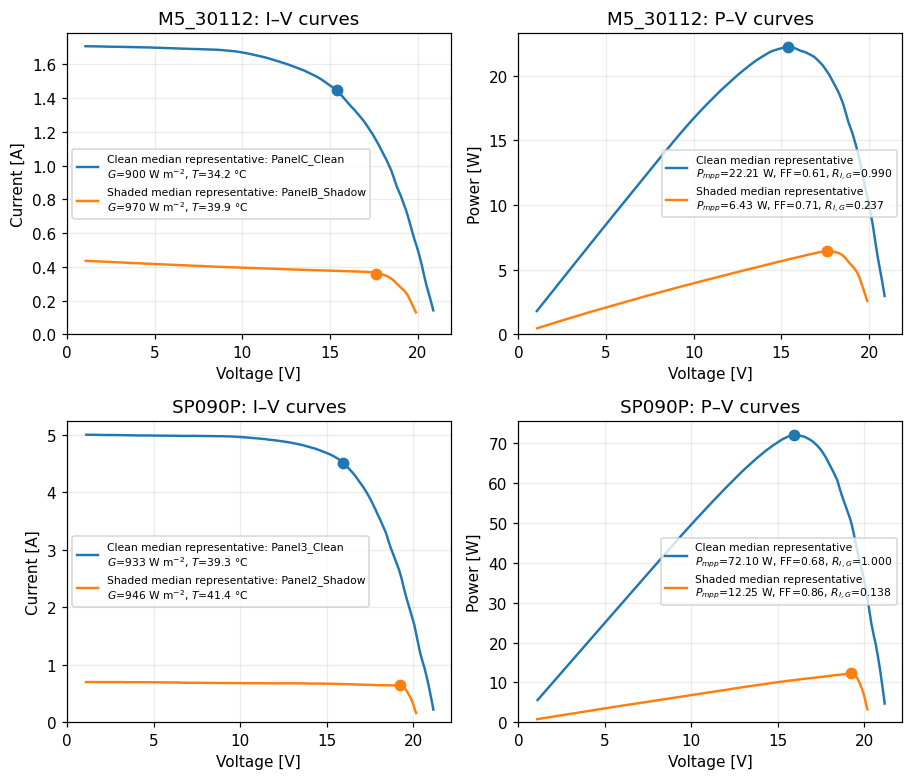

Figure 3 representative traces:
   panel condition         trace  G_Wm2  T_C      R_P    R_I_G  Pmpp_W       FF      Pmpp_source
M5_30112     Clean  PanelC_Clean  900.0 34.2 0.996105 0.989994   22.21 0.613929 dataset_reported
M5_30112    Shaded PanelB_Shadow  970.0 39.9 0.267571 0.236732    6.43 0.712860 dataset_reported
  SP090P     Clean  Panel3_Clean  933.0 39.3 1.014286 1.000000   72.10 0.676293 dataset_reported
  SP090P    Shaded Panel2_Shadow  946.0 41.4 0.169962 0.137933   12.25 0.862069 dataset_reported


In [34]:
# ================================================================
# 16. Figure 3 — median clean and median shaded I–V/P–V curves
# ================================================================

if "save_figure" not in globals():

    def save_figure(
        fig: plt.Figure,
        filename_stem: str,
    ) -> None:
        png_path = FIG_DIR / f"{filename_stem}.png"
        pdf_path = FIG_DIR / f"{filename_stem}.pdf"

        fig.savefig(
            png_path,
            dpi=SAVE_DPI,
            bbox_inches="tight",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        print("Saved:", png_path)
        print("Saved:", pdf_path)


def select_trace_nearest_condition_median(
    data: pd.DataFrame,
    panel: str,
    condition: str,
    metric: str = "R_P",
) -> pd.Series:
    """
    Select the trace whose metric is closest to the within-condition
    median. This applies the same representative-selection rule to
    clean and shaded conditions.
    """
    candidates = data.loc[
        (data["panel"] == panel)
        & (data["condition"] == condition)
        & data[metric].notna()
    ].copy()

    if candidates.empty:
        raise RuntimeError(
            f"No valid {condition} traces were found for "
            f"{panel}, using metric {metric}."
        )

    condition_median = float(
        candidates[metric].median()
    )

    selected_index = (
        candidates[metric]
        .sub(condition_median)
        .abs()
        .idxmin()
    )

    return candidates.loc[selected_index]


panel_order = sorted(
    df["panel"].unique()
)

fig, axes = plt.subplots(
    len(panel_order),
    2,
    figsize=(8.4, 3.6 * len(panel_order)),
    squeeze=False,
)

figure_3_selection_rows = []


for row_index, panel in enumerate(panel_order):

    clean_trace = select_trace_nearest_condition_median(
        data=df,
        panel=panel,
        condition="Clean",
        metric="R_P",
    )

    shaded_trace = select_trace_nearest_condition_median(
        data=df,
        panel=panel,
        condition="Shaded",
        metric="R_P",
    )

    iv_axis = axes[row_index, 0]
    pv_axis = axes[row_index, 1]

    selected_traces = [
        (
            clean_trace,
            "Clean median representative",
        ),
        (
            shaded_trace,
            "Shaded median representative",
        ),
    ]

    for selected_row, condition_label in selected_traces:

        trace_key = selected_row["trace_key"]

        if trace_key not in curve_store:
            raise KeyError(
                f"Trace key '{trace_key}' was not found in curve_store."
            )

        curve = curve_store[trace_key]

        voltage = np.asarray(
            curve["voltage_V"],
            dtype=float,
        )

        current = np.asarray(
            curve["current_A"],
            dtype=float,
        )

        power = np.asarray(
            curve["power_W"],
            dtype=float,
        )

        iv_label = (
            f"{condition_label}: {selected_row['trace']}\n"
            f"$G$={selected_row['G_Wm2']:.0f} W m$^{{-2}}$, "
            f"$T$={selected_row['T_C']:.1f} °C"
        )

        pv_label = (
            f"{condition_label}\n"
            f"$P_{{mpp}}$={selected_row['Pmpp_W']:.2f} W, "
            f"FF={selected_row['FF']:.2f}, "
            f"$R_{{I,G}}$={selected_row['R_I_G']:.3f}"
        )

        iv_axis.plot(
            voltage,
            current,
            linewidth=1.6,
            label=iv_label,
        )

        pv_axis.plot(
            voltage,
            power,
            linewidth=1.6,
            label=pv_label,
        )

        # Mark the final selected MPP on both curves.
        iv_axis.scatter(
            selected_row["Vmpp_V"],
            selected_row["Impp_A"],
            s=45,
            marker="o",
            zorder=4,
        )

        pv_axis.scatter(
            selected_row["Vmpp_V"],
            selected_row["Pmpp_W"],
            s=45,
            marker="o",
            zorder=4,
        )

        figure_3_selection_rows.append(
            {
                "figure": "Fig3",
                "panel": panel,
                "condition": selected_row["condition"],
                "selection_rule": (
                    "trace nearest to within-condition median R_P"
                ),
                "trace": selected_row["trace"],
                "G_Wm2": selected_row["G_Wm2"],
                "T_C": selected_row["T_C"],
                "R_P": selected_row["R_P"],
                "R_I_G": selected_row["R_I_G"],
                "Pmpp_W": selected_row["Pmpp_W"],
                "Vmpp_V": selected_row["Vmpp_V"],
                "Impp_A": selected_row["Impp_A"],
                "FF": selected_row["FF"],
                "Pmpp_source": selected_row["Pmpp_source"],
            }
        )

    # -------------------------------------------------------------
    # I–V panel formatting
    # -------------------------------------------------------------

    iv_axis.set_title(
        f"{panel}: I–V curves"
    )

    iv_axis.set_xlabel(
        "Voltage [V]"
    )

    iv_axis.set_ylabel(
        "Current [A]"
    )

    iv_axis.set_xlim(
        left=0
    )

    iv_axis.set_ylim(
        bottom=0
    )

    iv_axis.legend(
        fontsize=7,
        loc="best",
    )

    # -------------------------------------------------------------
    # P–V panel formatting
    # -------------------------------------------------------------

    pv_axis.set_title(
        f"{panel}: P–V curves"
    )

    pv_axis.set_xlabel(
        "Voltage [V]"
    )

    pv_axis.set_ylabel(
        "Power [W]"
    )

    pv_axis.set_xlim(
        left=0
    )

    pv_axis.set_ylim(
        bottom=0
    )

    pv_axis.legend(
        fontsize=7,
        loc="best",
    )


fig.tight_layout()

save_figure(
    fig,
    "Fig3_median_clean_shaded_IV_PV",
)

plt.show()


# Save the representative-trace selection for transparency.
figure_3_trace_selection = pd.DataFrame(
    figure_3_selection_rows
)

figure_3_trace_selection.to_csv(
    TABLE_DIR / "Fig3_trace_selection.csv",
    index=False,
)

print("Figure 3 representative traces:")
print(
    figure_3_trace_selection[
        [
            "panel",
            "condition",
            "trace",
            "G_Wm2",
            "T_C",
            "R_P",
            "R_I_G",
            "Pmpp_W",
            "FF",
            "Pmpp_source",
        ]
    ].to_string(index=False)
)

## 17. Figure 4 — descriptive threshold sensitivity

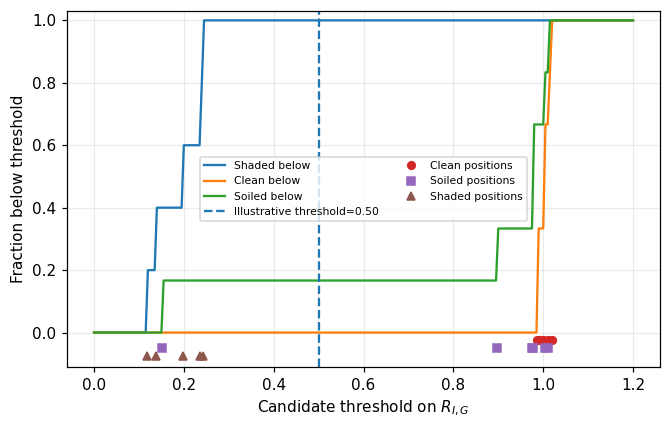

In [35]:
fig,ax=plt.subplots(figsize=(6.2,4.0)); ax.plot(threshold_table.threshold,threshold_table.shaded_below_fraction,label="Shaded below"); ax.plot(threshold_table.threshold,threshold_table.clean_below_fraction,label="Clean below"); ax.plot(threshold_table.threshold,threshold_table.soiled_below_fraction,label="Soiled below"); ax.axvline(ILLUSTRATIVE_THRESHOLD,ls="--",label=f"Illustrative threshold={ILLUSTRATIVE_THRESHOLD:.2f}")
rug={"Clean":-.025,"Soiled":-.05,"Shaded":-.075}
for cond in CONDITION_ORDER: ax.plot(df.loc[df.condition==cond,PRIMARY_INDEX],np.full((df.condition==cond).sum(),rug[cond]),ls="None",marker=markers[cond],ms=5,label=f"{cond} positions")
ax.set(xlabel=r"Candidate threshold on $R_{I,G}$",ylabel="Fraction below threshold",ylim=(-.11,1.03)); ax.legend(fontsize=7,ncol=2); fig.tight_layout(); save_fig(fig,"Fig4_threshold_sensitivity"); plt.show()

## 18. Figure 5 — temperature observations

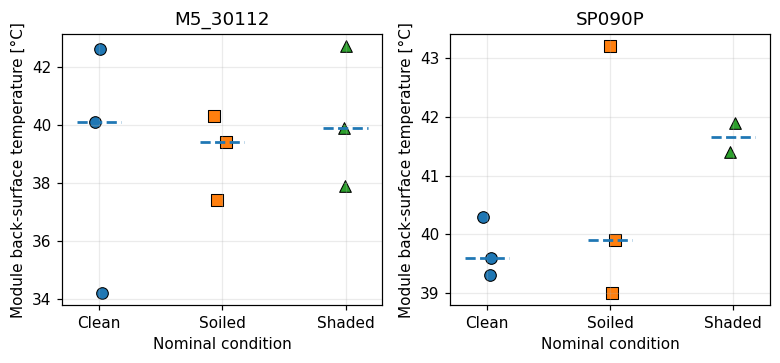

In [36]:
fig,axes=plt.subplots(1,len(panels),figsize=(7.2,3.4),squeeze=False); rng=np.random.default_rng(RANDOM_SEED)
for ax,panel in zip(axes[0],panels):
    sub=df[df.panel==panel]
    for j,cond in enumerate(CONDITION_ORDER):
        vals=sub.loc[sub.condition==cond,"T_C"].to_numpy(); ax.scatter(np.full(len(vals),j)+rng.normal(0,.035,len(vals)),vals,marker=markers[cond],s=58,edgecolor="black",linewidth=.7); ax.hlines(np.median(vals),j-.18,j+.18,ls="--",lw=1.8)
    ax.set(title=panel,xlabel="Nominal condition",ylabel="Module back-surface temperature [°C]"); ax.set_xticks(range(3)); ax.set_xticklabels(CONDITION_ORDER)
fig.tight_layout(); save_fig(fig,"Fig5_temperature_observations"); plt.show()

## 19. Figure 6 — anomalous soiled trace

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig6_SP090P_anomalous_soiled.png
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/figures/Fig6_SP090P_anomalous_soiled.pdf


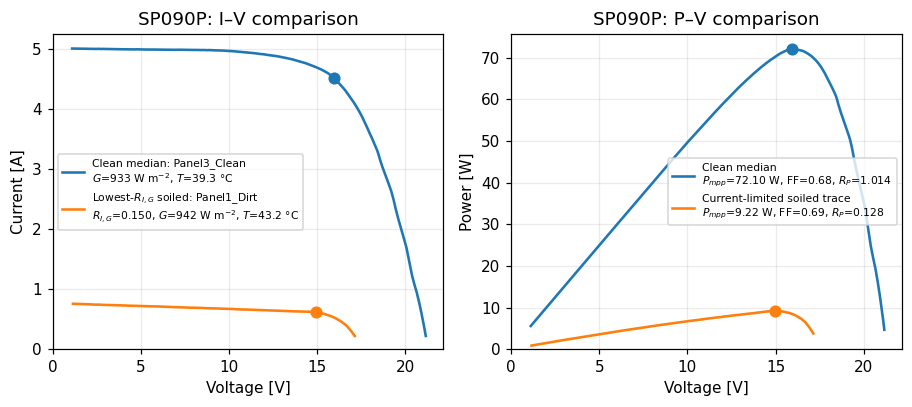

Figure 6 trace selection:
 panel condition             electrical_state        trace  G_Wm2  T_C      R_P    R_I_G  Pmpp_W       FF      Pmpp_source
SP090P     Clean   No severe current collapse Panel3_Clean  933.0 39.3 1.014286 1.000000   72.10 0.676293 dataset_reported
SP090P    Soiled Severe current-limited state  Panel1_Dirt  942.0 43.2 0.128466 0.150392    9.22 0.687342 dataset_reported


In [38]:
# ================================================================
# 19. Figure 6 — anomalous nominally soiled SP090P trace
# ================================================================

if "save_figure" not in globals():

    def save_figure(
        fig: plt.Figure,
        filename_stem: str,
    ) -> None:
        png_path = FIG_DIR / f"{filename_stem}.png"
        pdf_path = FIG_DIR / f"{filename_stem}.pdf"

        fig.savefig(
            png_path,
            dpi=SAVE_DPI,
            bbox_inches="tight",
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        print("Saved:", png_path)
        print("Saved:", pdf_path)


def select_trace_nearest_condition_median(
    data: pd.DataFrame,
    panel: str,
    condition: str,
    metric: str = "R_P",
) -> pd.Series:
    """
    Select the trace nearest to the within-condition median of a metric.
    """
    candidates = data.loc[
        (data["panel"] == panel)
        & (data["condition"] == condition)
        & data[metric].notna()
    ].copy()

    if candidates.empty:
        raise RuntimeError(
            f"No valid {condition} traces were found for "
            f"{panel}, using metric '{metric}'."
        )

    median_value = float(
        candidates[metric].median()
    )

    selected_index = (
        candidates[metric]
        .sub(median_value)
        .abs()
        .idxmin()
    )

    return candidates.loc[selected_index]


# ----------------------------------------------------------------
# Select the SP090P reference and anomalous soiled trace
# ----------------------------------------------------------------

target_panel = "SP090P"

clean_reference = select_trace_nearest_condition_median(
    data=df,
    panel=target_panel,
    condition="Clean",
    metric="R_P",
)

soiled_candidates = df.loc[
    (df["panel"] == target_panel)
    & (df["condition"] == "Soiled")
    & df[PRIMARY_INDEX].notna()
].copy()

if soiled_candidates.empty:
    raise RuntimeError(
        f"No valid nominally soiled traces were found for {target_panel}."
    )

# The anomalous trace is selected generically as the nominally soiled
# trace having the lowest irradiance-normalized current index.
anomalous_soiled = soiled_candidates.loc[
    soiled_candidates[PRIMARY_INDEX].idxmin()
]


# ----------------------------------------------------------------
# Retrieve the stored curves
# ----------------------------------------------------------------

clean_trace_key = clean_reference["trace_key"]
soiled_trace_key = anomalous_soiled["trace_key"]

if clean_trace_key not in curve_store:
    raise KeyError(
        f"Clean trace key '{clean_trace_key}' was not found in curve_store."
    )

if soiled_trace_key not in curve_store:
    raise KeyError(
        f"Soiled trace key '{soiled_trace_key}' was not found in curve_store."
    )

clean_curve = curve_store[clean_trace_key]
soiled_curve = curve_store[soiled_trace_key]

clean_voltage = np.asarray(
    clean_curve["voltage_V"],
    dtype=float,
)

clean_current = np.asarray(
    clean_curve["current_A"],
    dtype=float,
)

clean_power = np.asarray(
    clean_curve["power_W"],
    dtype=float,
)

soiled_voltage = np.asarray(
    soiled_curve["voltage_V"],
    dtype=float,
)

soiled_current = np.asarray(
    soiled_curve["current_A"],
    dtype=float,
)

soiled_power = np.asarray(
    soiled_curve["power_W"],
    dtype=float,
)


# ----------------------------------------------------------------
# Construct labels without broken multiline strings
# ----------------------------------------------------------------

clean_iv_label = (
    f"Clean median: {clean_reference['trace']}\n"
    f"$G$={clean_reference['G_Wm2']:.0f} W m$^{{-2}}$, "
    f"$T$={clean_reference['T_C']:.1f} °C"
)

soiled_iv_label = (
    f"Lowest-$R_{{I,G}}$ soiled: {anomalous_soiled['trace']}\n"
    f"$R_{{I,G}}$={anomalous_soiled['R_I_G']:.3f}, "
    f"$G$={anomalous_soiled['G_Wm2']:.0f} W m$^{{-2}}$, "
    f"$T$={anomalous_soiled['T_C']:.1f} °C"
)

clean_pv_label = (
    f"Clean median\n"
    f"$P_{{mpp}}$={clean_reference['Pmpp_W']:.2f} W, "
    f"FF={clean_reference['FF']:.2f}, "
    f"$R_P$={clean_reference['R_P']:.3f}"
)

soiled_pv_label = (
    f"Current-limited soiled trace\n"
    f"$P_{{mpp}}$={anomalous_soiled['Pmpp_W']:.2f} W, "
    f"FF={anomalous_soiled['FF']:.2f}, "
    f"$R_P$={anomalous_soiled['R_P']:.3f}"
)


# ----------------------------------------------------------------
# Plot I–V and P–V curves
# ----------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.4, 3.8),
)

iv_axis, pv_axis = axes


# I–V panel
iv_axis.plot(
    clean_voltage,
    clean_current,
    linewidth=1.7,
    label=clean_iv_label,
)

iv_axis.plot(
    soiled_voltage,
    soiled_current,
    linewidth=1.7,
    label=soiled_iv_label,
)

iv_axis.scatter(
    clean_reference["Vmpp_V"],
    clean_reference["Impp_A"],
    s=48,
    marker="o",
    zorder=4,
)

iv_axis.scatter(
    anomalous_soiled["Vmpp_V"],
    anomalous_soiled["Impp_A"],
    s=48,
    marker="o",
    zorder=4,
)

iv_axis.set_xlabel(
    "Voltage [V]"
)

iv_axis.set_ylabel(
    "Current [A]"
)

iv_axis.set_title(
    f"{target_panel}: I–V comparison"
)

iv_axis.set_xlim(
    left=0
)

iv_axis.set_ylim(
    bottom=0
)

iv_axis.legend(
    fontsize=7,
    loc="best",
)


# P–V panel
pv_axis.plot(
    clean_voltage,
    clean_power,
    linewidth=1.7,
    label=clean_pv_label,
)

pv_axis.plot(
    soiled_voltage,
    soiled_power,
    linewidth=1.7,
    label=soiled_pv_label,
)

pv_axis.scatter(
    clean_reference["Vmpp_V"],
    clean_reference["Pmpp_W"],
    s=48,
    marker="o",
    zorder=4,
)

pv_axis.scatter(
    anomalous_soiled["Vmpp_V"],
    anomalous_soiled["Pmpp_W"],
    s=48,
    marker="o",
    zorder=4,
)

pv_axis.set_xlabel(
    "Voltage [V]"
)

pv_axis.set_ylabel(
    "Power [W]"
)

pv_axis.set_title(
    f"{target_panel}: P–V comparison"
)

pv_axis.set_xlim(
    left=0
)

pv_axis.set_ylim(
    bottom=0
)

pv_axis.legend(
    fontsize=7,
    loc="best",
)


fig.tight_layout()

save_figure(
    fig,
    "Fig6_SP090P_anomalous_soiled",
)

plt.show()


# ----------------------------------------------------------------
# Export the exact traces used in Figure 6
# ----------------------------------------------------------------

figure_6_trace_selection = pd.DataFrame(
    [
        {
            "figure": "Fig6",
            "panel": target_panel,
            "condition": clean_reference["condition"],
            "electrical_state": clean_reference["electrical_state"],
            "selection_rule": (
                "trace nearest to the clean-condition median R_P"
            ),
            "trace": clean_reference["trace"],
            "G_Wm2": clean_reference["G_Wm2"],
            "T_C": clean_reference["T_C"],
            "R_P": clean_reference["R_P"],
            "R_I_G": clean_reference["R_I_G"],
            "Pmpp_W": clean_reference["Pmpp_W"],
            "Vmpp_V": clean_reference["Vmpp_V"],
            "Impp_A": clean_reference["Impp_A"],
            "FF": clean_reference["FF"],
            "Pmpp_source": clean_reference["Pmpp_source"],
        },
        {
            "figure": "Fig6",
            "panel": target_panel,
            "condition": anomalous_soiled["condition"],
            "electrical_state": anomalous_soiled["electrical_state"],
            "selection_rule": (
                "minimum R_I_G among nominally soiled SP090P traces"
            ),
            "trace": anomalous_soiled["trace"],
            "G_Wm2": anomalous_soiled["G_Wm2"],
            "T_C": anomalous_soiled["T_C"],
            "R_P": anomalous_soiled["R_P"],
            "R_I_G": anomalous_soiled["R_I_G"],
            "Pmpp_W": anomalous_soiled["Pmpp_W"],
            "Vmpp_V": anomalous_soiled["Vmpp_V"],
            "Impp_A": anomalous_soiled["Impp_A"],
            "FF": anomalous_soiled["FF"],
            "Pmpp_source": anomalous_soiled["Pmpp_source"],
        },
    ]
)

figure_6_trace_selection.to_csv(
    TABLE_DIR / "Fig6_trace_selection.csv",
    index=False,
)

print("Figure 6 trace selection:")
print(
    figure_6_trace_selection[
        [
            "panel",
            "condition",
            "electrical_state",
            "trace",
            "G_Wm2",
            "T_C",
            "R_P",
            "R_I_G",
            "Pmpp_W",
            "FF",
            "Pmpp_source",
        ]
    ].to_string(index=False)
)

## 20. Export canonical outputs and run manifest

In [41]:
# ----------------------------------------------------------------
# Export important analysis tables without failing on missing ones
# ----------------------------------------------------------------

candidate_tables = {
    "clean_references_v3.csv": "references",
    "condition_summary_v3.csv": "condition_summary",
    "condition_summary_extended_v3.csv": "condition_summary_extended",
    "relative_power_reductions_v3.csv": "relative_losses",
    "power_loss_decomposition_summary_v3.csv": "decomposition_summary",
    "regression_summary_v3.csv": "regression_table",
    "leave_one_trace_out_v3.csv": "loo",
    "leave_one_trace_out_summary_v3.csv": "loo_summary",
    "module_interaction_model_v3.csv": "interaction_table",
    "threshold_sensitivity_v3.csv": "threshold_table",
    "observed_threshold_separation_v3.csv": "separation",
    "reference_method_sensitivity_v3.csv": "reference_sensitivity",
    "reported_vs_reconstructed_summary_v3.csv": "validation_summary",
    "mpp_consistency_audit_v3.csv": "mpp_audit_table",
}

exported_tables = []
missing_tables = []

for filename, variable_name in candidate_tables.items():

    if variable_name not in globals():
        missing_tables.append(
            {
                "filename": filename,
                "variable": variable_name,
            }
        )
        continue

    table = globals()[variable_name]

    if not isinstance(table, pd.DataFrame):
        missing_tables.append(
            {
                "filename": filename,
                "variable": variable_name,
            }
        )
        continue

    output_path = TABLE_DIR / filename

    table.to_csv(
        output_path,
        index=False,
    )

    exported_tables.append(
        {
            "filename": filename,
            "variable": variable_name,
            "rows": len(table),
            "path": str(output_path),
        }
    )


exported_tables_df = pd.DataFrame(
    exported_tables
)

missing_tables_df = pd.DataFrame(
    missing_tables
)

exported_tables_df.to_csv(
    TABLE_DIR / "exported_analysis_tables.csv",
    index=False,
)

if not missing_tables_df.empty:
    missing_tables_df.to_csv(
        TABLE_DIR / "missing_optional_tables.csv",
        index=False,
    )


print(
    "Canonical analysis tables exported:",
    len(exported_tables_df),
)

if not exported_tables_df.empty:
    print(
        "\nExported tables:"
    )
    print(
        exported_tables_df[
            [
                "filename",
                "rows",
            ]
        ].to_string(index=False)
    )

if not missing_tables_df.empty:
    print(
        "\nOptional tables not found in the current session:"
    )
    print(
        missing_tables_df.to_string(
            index=False
        )
    )

Canonical analysis tables exported: 11

Exported tables:
                                filename  rows
                 clean_references_v3.csv     2
                condition_summary_v3.csv     6
       condition_summary_extended_v3.csv     6
        relative_power_reductions_v3.csv     4
               regression_summary_v3.csv     4
         module_interaction_model_v3.csv     4
            threshold_sensitivity_v3.csv   241
    observed_threshold_separation_v3.csv     1
     reference_method_sensitivity_v3.csv    24
reported_vs_reconstructed_summary_v3.csv     5
            mpp_consistency_audit_v3.csv    17

Optional tables not found in the current session:
                               filename              variable
power_loss_decomposition_summary_v3.csv decomposition_summary
             leave_one_trace_out_v3.csv                   loo
     leave_one_trace_out_summary_v3.csv           loo_summary


In [42]:
# ================================================================
# Recreate leave-one-trace-out regression sensitivity
# ================================================================

def basic_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
) -> dict:
    subset = data[
        [
            x_col,
            y_col,
        ]
    ].dropna()

    x = subset[x_col].to_numpy(
        dtype=float
    )

    y = subset[y_col].to_numpy(
        dtype=float
    )

    if (
        len(subset) < 3
        or np.unique(x).size < 2
    ):
        return {
            "n": int(len(subset)),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "slope": np.nan,
            "intercept": np.nan,
            "R2": np.nan,
            "rmse": np.nan,
        }

    pearson_r, pearson_p = stats.pearsonr(
        x,
        y,
    )

    spearman_rho, spearman_p = stats.spearmanr(
        x,
        y,
    )

    fit = stats.linregress(
        x,
        y,
    )

    predicted = (
        fit.intercept
        + fit.slope * x
    )

    residual_sum = float(
        np.sum(
            (
                y
                - predicted
            )
            ** 2
        )
    )

    total_sum = float(
        np.sum(
            (
                y
                - np.mean(y)
            )
            ** 2
        )
    )

    r_squared = (
        float(
            1.0
            - residual_sum / total_sum
        )
        if total_sum > 0
        else np.nan
    )

    rmse = float(
        np.sqrt(
            np.mean(
                (
                    y
                    - predicted
                )
                ** 2
            )
        )
    )

    return {
        "n": int(len(subset)),
        "pearson_r": float(pearson_r),
        "pearson_p": float(pearson_p),
        "spearman_rho": float(spearman_rho),
        "spearman_p": float(spearman_p),
        "slope": float(fit.slope),
        "intercept": float(fit.intercept),
        "R2": r_squared,
        "rmse": rmse,
    }


leave_one_out_rows = []

for omitted_index, omitted_row in df.iterrows():

    reduced_data = df.drop(
        index=omitted_index
    )

    result = basic_regression(
        data=reduced_data,
        x_col=PRIMARY_INDEX,
        y_col="R_P",
    )

    leave_one_out_rows.append(
        {
            "omitted_panel": omitted_row["panel"],
            "omitted_trace": omitted_row["trace"],
            "omitted_condition": omitted_row["condition"],
            "omitted_R_I_G": omitted_row["R_I_G"],
            "omitted_R_P": omitted_row["R_P"],
            **result,
        }
    )


loo = pd.DataFrame(
    leave_one_out_rows
)

loo_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "minimum": float(
                loo[metric].min()
            ),
            "maximum": float(
                loo[metric].max()
            ),
            "median": float(
                loo[metric].median()
            ),
            "mean": float(
                loo[metric].mean()
            ),
        }
        for metric in [
            "slope",
            "intercept",
            "pearson_r",
            "spearman_rho",
            "R2",
            "rmse",
        ]
    ]
)


loo.to_csv(
    TABLE_DIR / "leave_one_trace_out_v3.csv",
    index=False,
)

loo_summary.to_csv(
    TABLE_DIR / "leave_one_trace_out_summary_v3.csv",
    index=False,
)


print("Leave-one-trace-out results:")
print(
    loo[
        [
            "omitted_panel",
            "omitted_trace",
            "omitted_condition",
            "slope",
            "intercept",
            "pearson_r",
            "spearman_rho",
            "R2",
            "rmse",
        ]
    ].to_string(
        index=False
    )
)

print("\nLeave-one-trace-out summary:")
print(
    loo_summary.to_string(
        index=False
    )
)

Leave-one-trace-out results:
omitted_panel omitted_trace omitted_condition    slope  intercept  pearson_r  spearman_rho       R2     rmse
     M5_30112  PanelA_Clean             Clean 0.959542   0.038815   0.982680      0.753495 0.965660 0.070866
     M5_30112  PanelB_Clean             Clean 0.968231   0.036974   0.982370      0.767647 0.965050 0.072265
     M5_30112  PanelC_Clean             Clean 0.966646   0.037283   0.982331      0.766740 0.964974 0.072318
     M5_30112 PanelA_Shadow            Shaded 0.973022   0.030894   0.981771      0.700515 0.963874 0.071883
     M5_30112 PanelB_Shadow            Shaded 0.967161   0.036930   0.981289      0.700515 0.962927 0.072319
     M5_30112 PanelC_Shadow            Shaded 0.973603   0.030488   0.981436      0.700515 0.963217 0.071893
     M5_30112   PanelA_Dirt            Soiled 0.962594   0.038155   0.982332      0.753495 0.964977 0.071827
     M5_30112   PanelB_Dirt            Soiled 0.967226   0.037188   0.982408      0.753495 0.965125

In [45]:
# ================================================================
# 19B. Recreate power-loss decomposition summary for export
# ================================================================

decomposition_required_columns = [
    "R_P",
    "R_I_G",
    "R_V",
    "R_FF",
]

missing_columns = [
    column
    for column in decomposition_required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "Cannot construct decomposition summary. "
        f"Missing columns: {missing_columns}"
    )


# Log terms are used only for strictly positive factors.
positive_mask = (
    (df["R_P"] > 0)
    & (df["R_I_G"] > 0)
    & (df["R_V"] > 0)
    & (df["R_FF"] > 0)
)

df["ln_R_P"] = np.nan
df["ln_R_I_G"] = np.nan
df["ln_R_V"] = np.nan
df["ln_R_FF"] = np.nan

df.loc[
    positive_mask,
    "ln_R_P",
] = np.log(
    df.loc[
        positive_mask,
        "R_P",
    ]
)

df.loc[
    positive_mask,
    "ln_R_I_G",
] = np.log(
    df.loc[
        positive_mask,
        "R_I_G",
    ]
)

df.loc[
    positive_mask,
    "ln_R_V",
] = np.log(
    df.loc[
        positive_mask,
        "R_V",
    ]
)

df.loc[
    positive_mask,
    "ln_R_FF",
] = np.log(
    df.loc[
        positive_mask,
        "R_FF",
    ]
)


df["ln_factor_sum"] = (
    df["ln_R_I_G"]
    + df["ln_R_V"]
    + df["ln_R_FF"]
)

df["ln_decomposition_residual"] = (
    df["ln_R_P"]
    - df["ln_factor_sum"]
)


absolute_log_total = (
    df["ln_R_I_G"].abs()
    + df["ln_R_V"].abs()
    + df["ln_R_FF"].abs()
)

df["current_log_share"] = np.where(
    absolute_log_total > 0,
    df["ln_R_I_G"].abs()
    / absolute_log_total,
    np.nan,
)

df["voltage_log_share"] = np.where(
    absolute_log_total > 0,
    df["ln_R_V"].abs()
    / absolute_log_total,
    np.nan,
)

df["ff_log_share"] = np.where(
    absolute_log_total > 0,
    df["ln_R_FF"].abs()
    / absolute_log_total,
    np.nan,
)


decomposition_summary = (
    df.groupby(
        [
            "panel",
            "condition",
        ],
        observed=False,
    )
    .agg(
        n=("trace", "size"),

        R_P_mean=("R_P", "mean"),
        R_P_median=("R_P", "median"),

        R_I_G_mean=("R_I_G", "mean"),
        R_I_G_median=("R_I_G", "median"),

        R_V_mean=("R_V", "mean"),
        R_V_median=("R_V", "median"),

        R_FF_mean=("R_FF", "mean"),
        R_FF_median=("R_FF", "median"),

        current_log_share_mean=(
            "current_log_share",
            "mean",
        ),
        current_log_share_median=(
            "current_log_share",
            "median",
        ),

        voltage_log_share_mean=(
            "voltage_log_share",
            "mean",
        ),
        voltage_log_share_median=(
            "voltage_log_share",
            "median",
        ),

        ff_log_share_mean=(
            "ff_log_share",
            "mean",
        ),
        ff_log_share_median=(
            "ff_log_share",
            "median",
        ),

        maximum_absolute_log_residual=(
            "ln_decomposition_residual",
            lambda values: float(
                values.abs().max()
            ),
        ),
    )
    .reset_index()
)


decomposition_path = (
    TABLE_DIR
    / "power_loss_decomposition_summary_v3.csv"
)

decomposition_summary.to_csv(
    decomposition_path,
    index=False,
)

print(
    "Saved:",
    decomposition_path,
)

print(
    decomposition_summary.to_string(
        index=False
    )
)

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/power_loss_decomposition_summary_v3.csv
   panel condition  n  R_P_mean  R_P_median  R_I_G_mean  R_I_G_median  R_V_mean  R_V_median  R_FF_mean  R_FF_median  current_log_share_mean  current_log_share_median  voltage_log_share_mean  voltage_log_share_median  ff_log_share_mean  ff_log_share_median  maximum_absolute_log_residual
M5_30112     Clean  3  1.019633    0.996105    1.000272      1.000000  0.987179    1.000000   1.033590     1.000000                0.229439                  0.067941                0.222597                  0.288167           0.547964             0.643892                   4.336809e-18
M5_30112    Shaded  3  0.275852    0.267571    0.226230      0.236732  0.967078    0.973409   1.265728     1.302540                0.848758                  0.858050                0.019559                  0.016665           0.131683             0.140434                   2.22044

In [47]:
# ================================================================
# 20. Export canonical outputs and reproducibility manifest
# ================================================================

# ----------------------------------------------------------------
# 20.1 Combine figure-trace selections
# ----------------------------------------------------------------

figure_selection_tables = []

if "figure_3_trace_selection" in globals():
    figure_selection_tables.append(
        figure_3_trace_selection.copy()
    )

if "figure_6_trace_selection" in globals():
    figure_selection_tables.append(
        figure_6_trace_selection.copy()
    )

if figure_selection_tables:
    figure_trace_selection = pd.concat(
        figure_selection_tables,
        ignore_index=True,
        sort=False,
    )

    figure_trace_selection.to_csv(
        TABLE_DIR / "figure_trace_selection.csv",
        index=False,
    )

    print(
        "Combined figure-trace selection saved:",
        TABLE_DIR / "figure_trace_selection.csv",
    )

else:
    figure_trace_selection = pd.DataFrame()

    print(
        "[WARNING] No figure-selection tables were found."
    )


# ----------------------------------------------------------------
# 20.2 Export trace-level results
# ----------------------------------------------------------------

requested_columns = [
    "panel",
    "trace",
    "condition",
    "electrical_state",
    "file",
    "G_Wm2",
    "T_C",
    "Isc_A",
    "Voc_V",
    "Pmpp_W",
    "Vmpp_V",
    "Impp_A",
    "FF",
    "Phi_m2",
    "Isc_per_G",
    "R_P",
    "R_I_G",
    "R_I_original",
    "R_V",
    "R_FF",
    "R_P_factor_product",
    "factor_product_abs_error",
    "factor_product_error_pct",
    "ln_R_P",
    "ln_R_I_G",
    "ln_R_V",
    "ln_R_FF",
    "ln_factor_sum",
    "ln_decomposition_residual",
    "current_log_share",
    "voltage_log_share",
    "ff_log_share",
    "Isc_source",
    "Voc_source",
    "Pmpp_source",
    "Vmpp_source",
    "Impp_source",
    "reported_mpp_consistent",
    "reported_mpp_failure_reason",
    "current_sign_flipped",
]

available_columns = [
    column
    for column in requested_columns
    if column in df.columns
]

missing_output_columns = [
    column
    for column in requested_columns
    if column not in df.columns
]

if missing_output_columns:
    print(
        "\n[INFO] Optional trace-level columns omitted:"
    )

    for column in missing_output_columns:
        print(" ", column)

trace_results = df[
    available_columns
].copy()

trace_csv_path = (
    TABLE_DIR
    / "trace_level_results_v3.csv"
)

full_audit_csv_path = (
    TABLE_DIR
    / "trace_level_full_audit_v3.csv"
)

trace_results.to_csv(
    trace_csv_path,
    index=False,
)

df.to_csv(
    full_audit_csv_path,
    index=False,
)

print("\nSaved:", trace_csv_path)
print("Saved:", full_audit_csv_path)

try:
    parquet_path = (
        TABLE_DIR
        / "trace_level_results_v3.parquet"
    )

    trace_results.to_parquet(
        parquet_path,
        index=False,
    )

    print("Saved:", parquet_path)

except Exception as error:
    print(
        "[INFO] Parquet export skipped:",
        error,
    )


# ----------------------------------------------------------------
# 20.3 Export stored I–V/P–V curves
# ----------------------------------------------------------------

CURVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

curve_export_count = 0

for trace_key, curve in curve_store.items():

    safe_filename = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        trace_key,
    )

    curve_path = (
        CURVE_DIR
        / f"{safe_filename}.csv"
    )

    curve_table = pd.DataFrame(
        {
            "voltage_V": curve["voltage_V"],
            "current_A": curve["current_A"],
            "power_W": curve["power_W"],
        }
    )

    curve_table.to_csv(
        curve_path,
        index=False,
    )

    curve_export_count += 1

print(
    "\nNumber of trace curves exported:",
    curve_export_count,
)


# ----------------------------------------------------------------
# 20.4 Export analysis tables safely
# ----------------------------------------------------------------

candidate_tables = {
    "clean_references_v3.csv": "references",
    "condition_summary_v3.csv": "condition_summary",
    "condition_summary_extended_v3.csv":
        "condition_summary_extended",
    "relative_power_reductions_v3.csv":
        "relative_losses",
    "power_loss_decomposition_summary_v3.csv":
        "decomposition_summary",
    "regression_summary_v3.csv":
        "regression_table",
    "leave_one_trace_out_v3.csv":
        "loo",
    "leave_one_trace_out_summary_v3.csv":
        "loo_summary",
    "module_interaction_model_v3.csv":
        "interaction_table",
    "threshold_sensitivity_v3.csv":
        "threshold_table",
    "observed_threshold_separation_v3.csv":
        "separation",
    "reference_method_sensitivity_v3.csv":
        "reference_sensitivity",
    "reported_vs_reconstructed_summary_v3.csv":
        "validation_summary",
    "mpp_consistency_audit_v3.csv":
        "mpp_audit_table",
}

exported_tables = []
missing_tables = []

for filename, variable_name in candidate_tables.items():

    if variable_name not in globals():
        missing_tables.append(
            {
                "filename": filename,
                "variable": variable_name,
            }
        )
        continue

    table = globals()[variable_name]

    if not isinstance(
        table,
        pd.DataFrame,
    ):
        missing_tables.append(
            {
                "filename": filename,
                "variable": variable_name,
            }
        )
        continue

    output_path = (
        TABLE_DIR
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
    )

    exported_tables.append(
        {
            "filename": filename,
            "variable": variable_name,
            "rows": int(len(table)),
            "path": str(output_path),
        }
    )


exported_tables_df = pd.DataFrame(
    exported_tables
)

missing_tables_df = pd.DataFrame(
    missing_tables
)

exported_tables_df.to_csv(
    TABLE_DIR
    / "exported_analysis_tables.csv",
    index=False,
)

if not missing_tables_df.empty:
    missing_tables_df.to_csv(
        TABLE_DIR
        / "missing_optional_tables.csv",
        index=False,
    )

print(
    "\nCanonical analysis tables exported:",
    len(exported_tables_df),
)

if not exported_tables_df.empty:
    print(
        "\nExported tables:"
    )

    print(
        exported_tables_df[
            [
                "filename",
                "rows",
            ]
        ].to_string(
            index=False
        )
    )

if not missing_tables_df.empty:
    print(
        "\nOptional tables not found:"
    )

    print(
        missing_tables_df.to_string(
            index=False
        )
    )


# ----------------------------------------------------------------
# 20.5 Write run manifest
# ----------------------------------------------------------------

condition_counts = (
    df.groupby(
        [
            "panel",
            "condition",
        ],
        observed=False,
    )
    .size()
)

panel_condition_counts = {}

for (
    panel,
    condition,
), count in condition_counts.items():

    if panel not in panel_condition_counts:
        panel_condition_counts[panel] = {}

    panel_condition_counts[panel][condition] = int(
        count
    )


mpp_source_counts = (
    df["Pmpp_source"]
    .value_counts(
        dropna=False
    )
    .to_dict()
)


run_summary = {
    "number_of_traces": int(
        len(df)
    ),

    "expected_number_of_traces": int(
        EXPECTED_TOTAL
    ),

    "panel_condition_counts":
        panel_condition_counts,

    "primary_index":
        PRIMARY_INDEX,

    "clean_reference_method": (
        "within-module clean medians with "
        "factor-consistent Phi reference"
    ),

    "illustrative_threshold": float(
        ILLUSTRATIVE_THRESHOLD
    ),

    "quantitative_statistics_use_clipping":
        False,

    "number_of_exported_curves": int(
        curve_export_count
    ),

    "number_of_exported_analysis_tables":
        int(len(exported_tables_df)),

    "missing_optional_table_variables": (
        missing_tables_df["variable"].tolist()
        if not missing_tables_df.empty
        else []
    ),

    "maximum_factor_product_error_pct": (
        float(
            df[
                "factor_product_error_pct"
            ].max()
        )
        if "factor_product_error_pct" in df.columns
        else None
    ),

    "mpp_source_counts": {
        str(key): int(value)
        for key, value
        in mpp_source_counts.items()
    },

    "number_of_reconstructed_mpp_traces": int(
        (
            df["Pmpp_source"]
            == (
                "reconstructed_after_"
                "consistency_failure"
            )
        ).sum()
    ),

    "reconstructed_mpp_trace_ids": (
        df.loc[
            df["Pmpp_source"]
            == (
                "reconstructed_after_"
                "consistency_failure"
            ),
            [
                "panel",
                "trace",
            ],
        ]
        .astype(str)
        .agg(
            "::".join,
            axis=1,
        )
        .tolist()
    ),

    "number_of_severe_current_limited_traces": int(
        (
            df["electrical_state"]
            == (
                "Severe current-limited state"
            )
        ).sum()
    ),
}


run_summary_path = (
    LOG_DIR
    / "run_summary.json"
)

with open(
    run_summary_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        run_summary,
        file,
        indent=2,
    )

print(
    "\nSaved:",
    run_summary_path,
)


# ----------------------------------------------------------------
# 20.6 Final integrity report
# ----------------------------------------------------------------

print(
    "\nFinal run summary:"
)

print(
    json.dumps(
        run_summary,
        indent=2,
    )
)

print(
    "\nCanonical v3 export completed successfully."
)

print(
    "Tables directory:",
    TABLE_DIR,
)

print(
    "Figures directory:",
    FIG_DIR,
)

print(
    "Curves directory:",
    CURVE_DIR,
)

print(
    "Logs directory:",
    LOG_DIR,
)

Combined figure-trace selection saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/figure_trace_selection.csv

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/trace_level_results_v3.csv
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/trace_level_full_audit_v3.csv
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs_v3/tables/trace_level_results_v3.parquet

Number of trace curves exported: 17

Canonical analysis tables exported: 14

Exported tables:
                                filename  rows
                 clean_references_v3.csv     2
                condition_summary_v3.csv     6
       condition_summary_extended_v3.csv     6
        relative_power_reductions_v3.csv     4
 power_loss_decomposition_summary_v3.csv     6
               regression_summary_v3.csv     4
        

## Interpretation guardrails

- `R_I_G` is an irradiance-normalized current-limitation severity index, not a uniquely mismatch-specific fault identifier.
- The pooled correlation is descriptive because normalized power contains current algebraically and the observations may be clustered by condition.
- The threshold is an illustrative in-sample boundary, not a universal classifier.
- Real-time use requires periodic I–V tracing or an online short-circuit-current estimator.
- The present evidence remains a two-module, 17-trace proof of concept.